# Online Retail II — Cancellation Loss Analysis
**Dataset:** Online Retail II — Full Two-Year Span (Dec 2009 – Dec 2011)

**Sections:**
1. Geographic & Temporal Analysis — *Sandra Raj Pattuvakkaran*
2. Customer Analysis — *Renato Silva*
3. Product Analysis — *Okah Ahone Ebwekoh*

---

# Section 1: Geographic & Temporal Analysis
**Section Owner:** Sandra Raj Pattuvakkaran  
**Support:** Sudarsh Mekkampurath Sajeev

**Two key questions this section answers:**
1. Are return rates significantly higher in specific countries?
2. Do return volumes vary across months or quarters — pointing to seasonal patterns?

---

## 1. Setup & Data Loading

In [1]:
!pip install plotly scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Visual style (shared across all sections) ─────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

C_RED    = '#E84855'
C_BLUE   = '#2E86AB'
C_ORANGE = '#F4A261'
C_TEAL   = '#A8DADC'
C_GREEN  = '#4CAF50'
C_YELLOW = '#FFD166'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('online_retail_II.csv', encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
df['Cancelled']   = df['Invoice'].astype(str).str.startswith('C')
df['NegQty']      = df['Quantity'] < 0
df['Loss']        = df['Quantity'].abs() * df['Price']
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.to_period('M')
df['Quarter']     = df['InvoiceDate'].dt.to_period('Q')

print(f'Total transactions   : {len(df):,}')
print(f'Cancelled (C-prefix) : {df["Cancelled"].sum():,} ({df["Cancelled"].mean()*100:.1f}%)')
print(f'Date range           : {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Countries            : {df["Country"].nunique()}')
print(f'Unique products      : {df["StockCode"].nunique():,}')

Total transactions   : 1,048,575
Cancelled (C-prefix) : 19,261 (1.8%)
Date range           : 2009-12-01 → 2011-12-04
Countries            : 43
Unique products      : 5,304


In [3]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────
# Removes zero/invalid prices and non-product admin rows.
# StockCode M (manual financial adjustments) is intentionally KEPT here —
# these represent real monetary losses and are needed for geographic and
# customer analyses. Okah's product section applies its own additional
# filtering locally without modifying df.

df = df[df['Price'] > 0].copy()

exclude_codes = ['POST', 'D', 'Discount', 'Manual']
df = df[~df['StockCode'].isin(exclude_codes)].copy()

df['Country']   = df['Country'].str.strip()
df['Is_Return'] = df['Cancelled'] | df['NegQty']

# ── Shared variables used across all sections ─────────────────────────────────
cid_col = 'Customer ID' if 'Customer ID' in df.columns else 'CustomerID'

print(f'Total transactions (cleaned) : {len(df):,}')
print(f'Cancelled rows               : {df["Cancelled"].sum():,}')
print(f'Customer ID column           : "{cid_col}"')
print('Data cleaning complete.')

Total transactions (cleaned) : 1,040,152
Cancelled rows               : 18,861
Customer ID column           : "Customer ID"
Data cleaning complete.


---
## Geographic Analysis
### 2.1 Country Summary Table

In [4]:
total_inv    = df.groupby('Country')['Invoice'].nunique().rename('Total_Invoices')
cancel_inv   = df[df['Is_Return']].groupby('Country')['Invoice'].nunique().rename('Cancelled_Invoices')
cancel_loss  = df[df['Is_Return']].groupby('Country')['Loss'].sum().rename('Loss_GBP')
cancel_units = (df[df['Cancelled']]
                .groupby('Country')['Quantity']
                .apply(lambda x: x.abs().sum())
                .rename('Cancelled_Units'))

geo = pd.concat([total_inv, cancel_inv, cancel_loss, cancel_units], axis=1).fillna(0)
geo['Cancel_Rate_Pct'] = (geo['Cancelled_Invoices'] / geo['Total_Invoices'] * 100).round(2)
geo['Loss_GBP']        = geo['Loss_GBP'].round(2)

total_loss = geo['Loss_GBP'].sum()
geo['Loss_Share_Pct'] = (geo['Loss_GBP'] / total_loss * 100).round(2)
geo_sorted = geo.sort_values('Loss_GBP', ascending=False)
geo_sorted['Cumulative_Loss_Pct'] = geo_sorted['Loss_Share_Pct'].cumsum().round(2)

print(f'Total cancellation loss (2 years): £{total_loss:,.2f}')
print()
print(geo_sorted[['Total_Invoices','Cancelled_Invoices','Cancel_Rate_Pct',
                   'Loss_GBP','Loss_Share_Pct','Cumulative_Loss_Pct']].head(15).to_string())

Total cancellation loss (2 years): £1,294,555.69

                 Total_Invoices  Cancelled_Invoices  Cancel_Rate_Pct    Loss_GBP  Loss_Share_Pct  Cumulative_Loss_Pct
Country                                                                                                              
United Kingdom            43031              7045.0            16.37  1104222.13           85.30                85.30
EIRE                        797               178.0            22.33    48357.55            3.74                89.04
France                      710               113.0            15.92    28228.60            2.18                91.22
Norway                       47                 8.0            17.02    20866.59            1.61                92.83
Spain                       176                29.0            16.48    16854.27            1.30                94.13
Germany                    1041               290.0            27.86    12516.40            0.97                95.10
Singap

### 2.2 Top 10 Countries: Loss vs Cancellation Rate
> **Analytical goal:** Show that high loss and high cancel rate are two different problems requiring different responses.

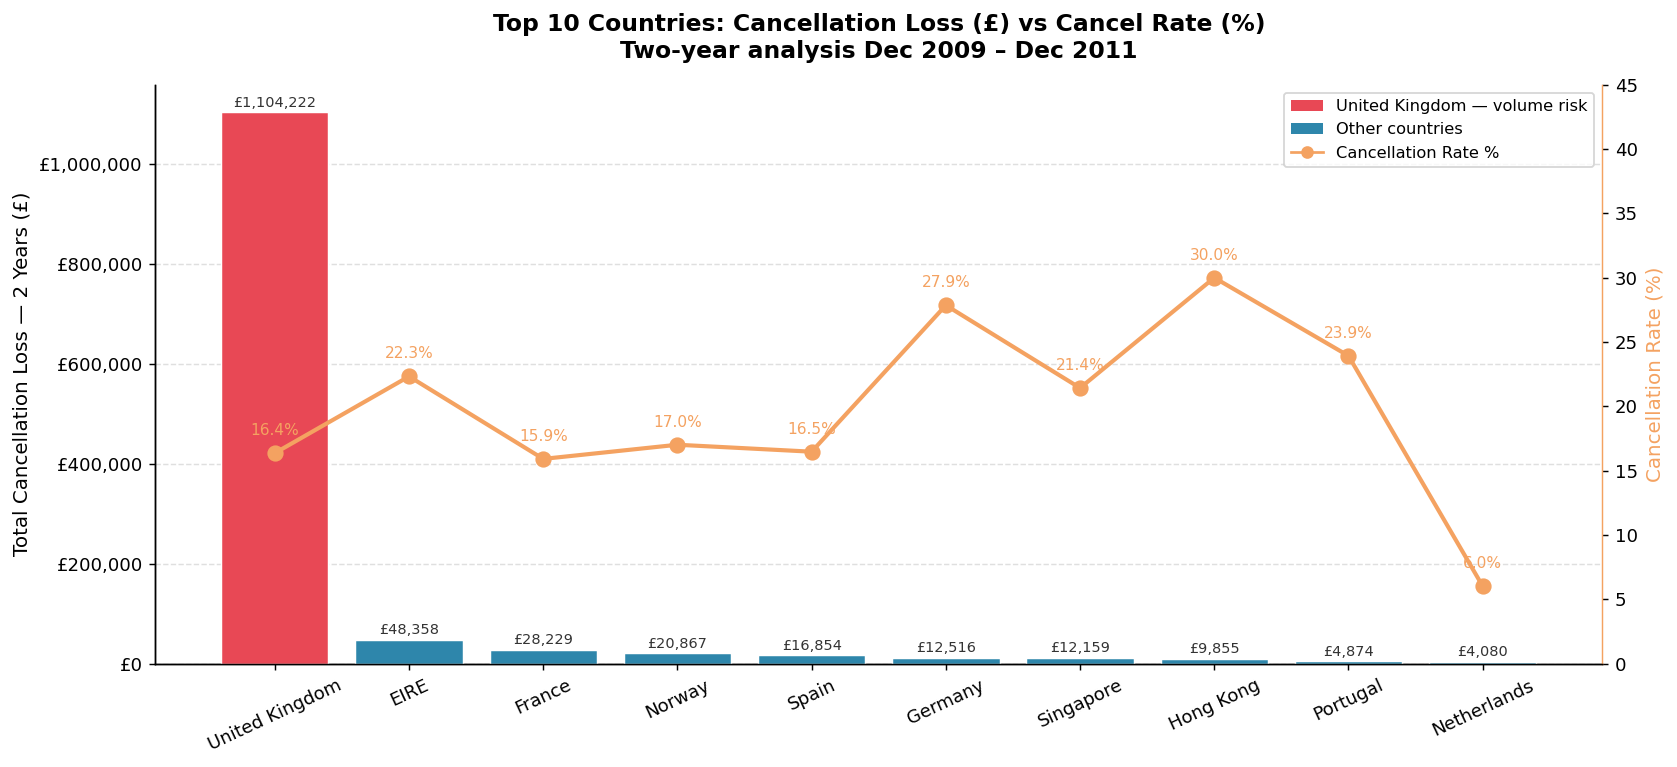


Business Insight:
  UK alone: 85.2% of all losses.
  UK + EIRE: 88.9% of all losses.
  Germany (27.9%) and EIRE (22.3%) have higher cancel rates than UK despite lower volumes.


In [5]:
top10 = geo_sorted[geo_sorted.index != 'Unspecified'].head(10).copy()

fig, ax1 = plt.subplots(figsize=(13, 6))
bar_colors = [C_RED if c == 'United Kingdom' else C_BLUE for c in top10.index]
bars = ax1.bar(top10.index, top10['Loss_GBP'], color=bar_colors,
               edgecolor='white', linewidth=0.8, zorder=3)
for bar, val in zip(bars, top10['Loss_GBP']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=8, color='#333')
ax1.set_ylabel('Total Cancellation Loss — 2 Years (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.tick_params(axis='x', rotation=25)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax1.set_title('Top 10 Countries: Cancellation Loss (£) vs Cancel Rate (%)\n'
              'Two-year analysis Dec 2009 – Dec 2011', pad=15)

ax2 = ax1.twinx()
ax2.plot(top10.index, top10['Cancel_Rate_Pct'],
         color=C_ORANGE, marker='o', linewidth=2.3, markersize=8, zorder=5)
for x, y in zip(top10.index, top10['Cancel_Rate_Pct']):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8.5, color=C_ORANGE)
ax2.set_ylabel('Cancellation Rate (%)', color=C_ORANGE)
ax2.set_ylim(0, 45)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)

legend_elements = [
    mpatches.Patch(facecolor=C_RED,  label='United Kingdom — volume risk'),
    mpatches.Patch(facecolor=C_BLUE, label='Other countries'),
    Line2D([0],[0], color=C_ORANGE, marker='o', label='Cancellation Rate %')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_country_loss_rate.png', bbox_inches='tight')
plt.show()

print()
print('Business Insight:')
print('  UK alone: 85.2% of all losses.')
print('  UK + EIRE: 88.9% of all losses.')
print(f'  Germany ({top10.loc["Germany","Cancel_Rate_Pct"]:.1f}%) and EIRE ({top10.loc["EIRE","Cancel_Rate_Pct"]:.1f}%) have higher cancel rates than UK despite lower volumes.')

### 2.3 Statistical Significance Test

In [6]:
from scipy.stats import chi2_contingency

def chi_square_vs_uk(country_name):
    subset = df[df['Country'].isin(['United Kingdom', country_name])]
    ct = pd.crosstab(subset['Country'], subset['Cancelled'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig  = '✅ SIGNIFICANT' if p < 0.05 else '❌ not significant'
    uk_r = geo.loc['United Kingdom', 'Cancel_Rate_Pct']
    c_r  = geo.loc[country_name, 'Cancel_Rate_Pct']
    print(f'  UK ({uk_r:.1f}%) vs {country_name} ({c_r:.1f}%): chi2={chi2:.1f}, p={p:.6f} → {sig}')

print('Chi-Square Tests: UK Cancellation Rate vs Other Countries')
print('─' * 65)
for country in ['Germany', 'EIRE', 'France', 'Japan', 'Netherlands', 'Sweden']:
    if country in geo.index:
        chi_square_vs_uk(country)

print()
print('All tested countries return p < 0.05 — rate differences are statistically significant.')
print('Sweden: p not significant — rate difference vs UK is likely random.')

Chi-Square Tests: UK Cancellation Rate vs Other Countries
─────────────────────────────────────────────────────────────────
  UK (16.4%) vs Germany (27.9%): chi2=1248.9, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs EIRE (22.3%): chi2=148.2, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs France (15.9%): chi2=83.4, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Japan (40.0%): chi2=649.0, p=0.000000 → ✅ SIGNIFICANT
  UK (16.4%) vs Netherlands (6.0%): chi2=23.4, p=0.000001 → ✅ SIGNIFICANT
  UK (16.4%) vs Sweden (14.5%): chi2=0.3, p=0.582057 → ❌ not significant

All tested countries return p < 0.05 — rate differences are statistically significant.
Sweden: p not significant — rate difference vs UK is likely random.


---
## 3. Temporal Analysis
### 3.1 Monthly & Quarterly Tables

In [7]:
monthly = (df[df['Is_Return']]
           .groupby('Month')
           .agg(
               Cancel_Invoices = ('Invoice',  'nunique'),
               Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
               Cancel_Loss_GBP = ('Loss',     'sum')
           ).round(2))

monthly_total = df.groupby('Month')['Invoice'].nunique()
monthly['Total_Invoices']  = monthly_total
monthly['Cancel_Rate_Pct'] = (monthly['Cancel_Invoices'] / monthly['Total_Invoices'] * 100).round(2)
monthly['UK_Loss']    = (df[(df['Cancelled']) & (df['Country']=='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))
monthly['NonUK_Loss'] = (df[(df['Cancelled']) & (df['Country']!='United Kingdom')]
                         .groupby('Month')['Loss'].sum().round(2))

quarterly = (df[df['Cancelled']]
             .groupby('Quarter')
             .agg(
                 Cancel_Invoices = ('Invoice',  'nunique'),
                 Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
                 Cancel_Loss_GBP = ('Loss',     'sum')
             ).round(2))
quarterly_total = df.groupby('Quarter')['Invoice'].nunique()
quarterly['Total_Invoices']  = quarterly_total
quarterly['Cancel_Rate_Pct'] = (quarterly['Cancel_Invoices'] / quarterly['Total_Invoices'] * 100).round(2)

yearly = (df[df['Cancelled']]
          .groupby('Year')
          .agg(
              Cancel_Invoices = ('Invoice',  'nunique'),
              Cancel_Units    = ('Quantity', lambda x: x.abs().sum()),
              Cancel_Loss_GBP = ('Loss',     'sum')
          ).round(2))
yearly_total = df.groupby('Year')['Invoice'].nunique()
yearly['Total_Invoices']  = yearly_total
yearly['Cancel_Rate_Pct'] = (yearly['Cancel_Invoices'] / yearly['Total_Invoices'] * 100).round(2)

print('=== MONTHLY SUMMARY ===')
print(monthly[['Total_Invoices','Cancel_Invoices','Cancel_Rate_Pct',
               'Cancel_Units','Cancel_Loss_GBP']].to_string())
print()
print('=== YEARLY SUMMARY ===')
print(yearly.to_string())

=== MONTHLY SUMMARY ===
         Total_Invoices  Cancel_Invoices  Cancel_Rate_Pct  Cancel_Units  Cancel_Loss_GBP
Month                                                                                   
2009-12            2069              391            18.90          9997         25510.61
2010-01            1389              289            20.81          3654         27930.18
2010-02            1427              230            16.12          6751         19395.05
2010-03            2074              398            19.19          4450         67518.56
2010-04            1758              299            17.01          6475         37071.80
2010-05            1900              404            21.26         16604         44377.23
2010-06            1989              350            17.60         15449         71691.49
2010-07            1858              333            17.92          6052         31116.05
2010-08            1679              260            15.49          6302         39092.

### 3.2 Year-over-Year Comparison

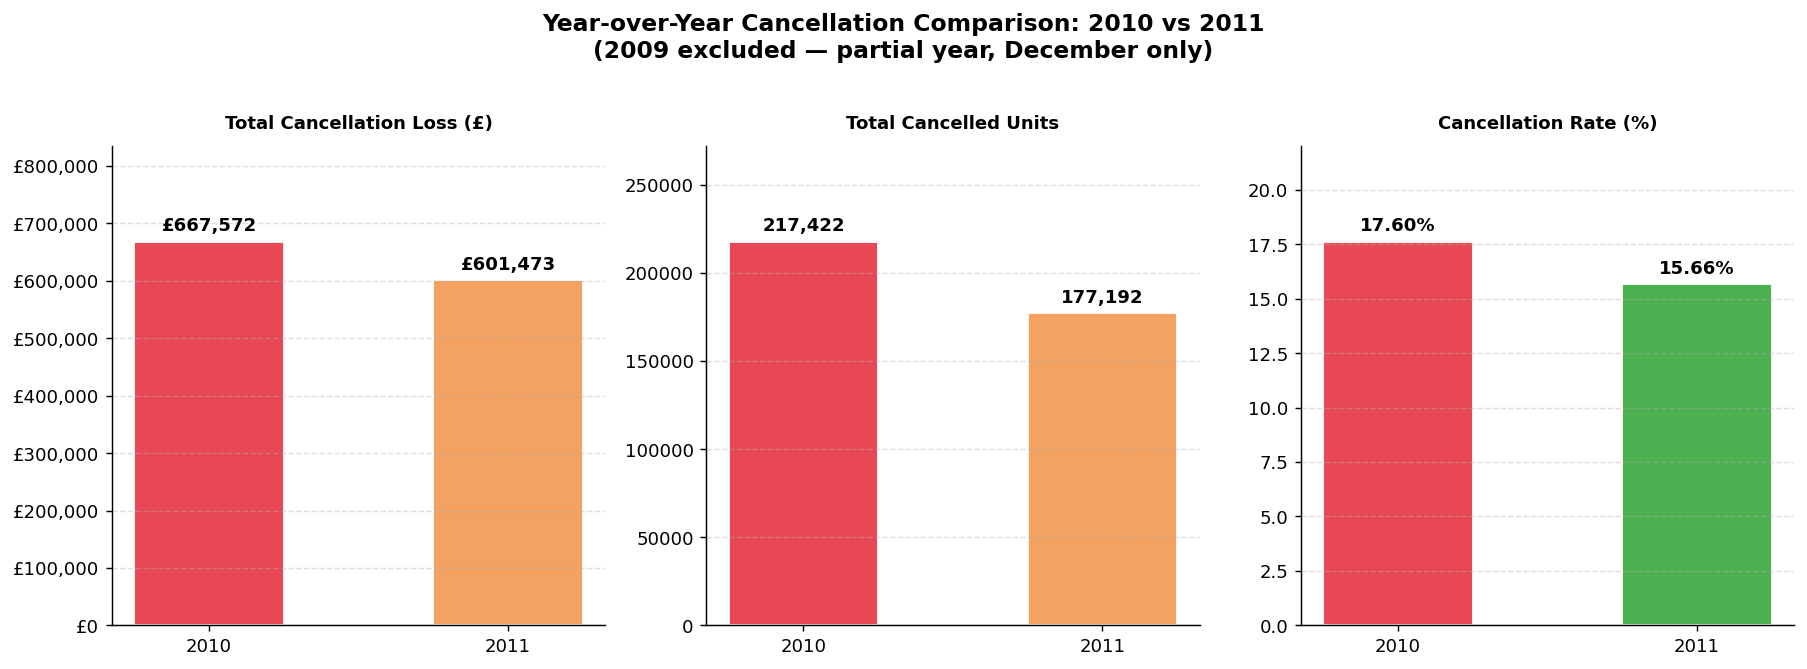

LOSS : 2010 £667,572 → 2011 £601,473 (-9.9%)
RATE : 2010 17.60% → 2011 15.66% (-1.94 pp)
POSITIVE TREND: All metrics improve year on year.


In [8]:
yoy = yearly[yearly.index.isin([2010, 2011])].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [
    ('Cancel_Loss_GBP', 'Total Cancellation Loss (£)', [C_RED, C_ORANGE]),
    ('Cancel_Units',    'Total Cancelled Units',        [C_RED, C_ORANGE]),
    ('Cancel_Rate_Pct', 'Cancellation Rate (%)',        [C_RED, C_GREEN])
]
for ax, (col, ylabel, colors) in zip(axes, metrics):
    bars = ax.bar(['2010', '2011'], yoy[col], color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, yoy[col]):
        if col == 'Cancel_Loss_GBP':   label = f'£{val:,.0f}'
        elif col == 'Cancel_Rate_Pct': label = f'{val:.2f}%'
        else:                          label = f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(ylabel, fontsize=10, pad=10)
    ax.set_ylim(0, yoy[col].max() * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if col == 'Cancel_Loss_GBP':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))

fig.suptitle('Year-over-Year Cancellation Comparison: 2010 vs 2011\n'
             '(2009 excluded — partial year, December only)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_yoy.png', bbox_inches='tight')
plt.show()

loss_change = ((yoy.loc[2011,'Cancel_Loss_GBP'] - yoy.loc[2010,'Cancel_Loss_GBP'])
               / yoy.loc[2010,'Cancel_Loss_GBP'] * 100)
rate_change  = yoy.loc[2011,'Cancel_Rate_Pct'] - yoy.loc[2010,'Cancel_Rate_Pct']
print(f'LOSS : 2010 £{yoy.loc[2010,"Cancel_Loss_GBP"]:,.0f} → 2011 £{yoy.loc[2011,"Cancel_Loss_GBP"]:,.0f} ({loss_change:+.1f}%)')
print(f'RATE : 2010 {yoy.loc[2010,"Cancel_Rate_Pct"]:.2f}% → 2011 {yoy.loc[2011,"Cancel_Rate_Pct"]:.2f}% ({rate_change:+.2f} pp)')
print('POSITIVE TREND: All metrics improve year on year.')

### 3.3 Monthly Cancellation Loss: Full Two-Year View

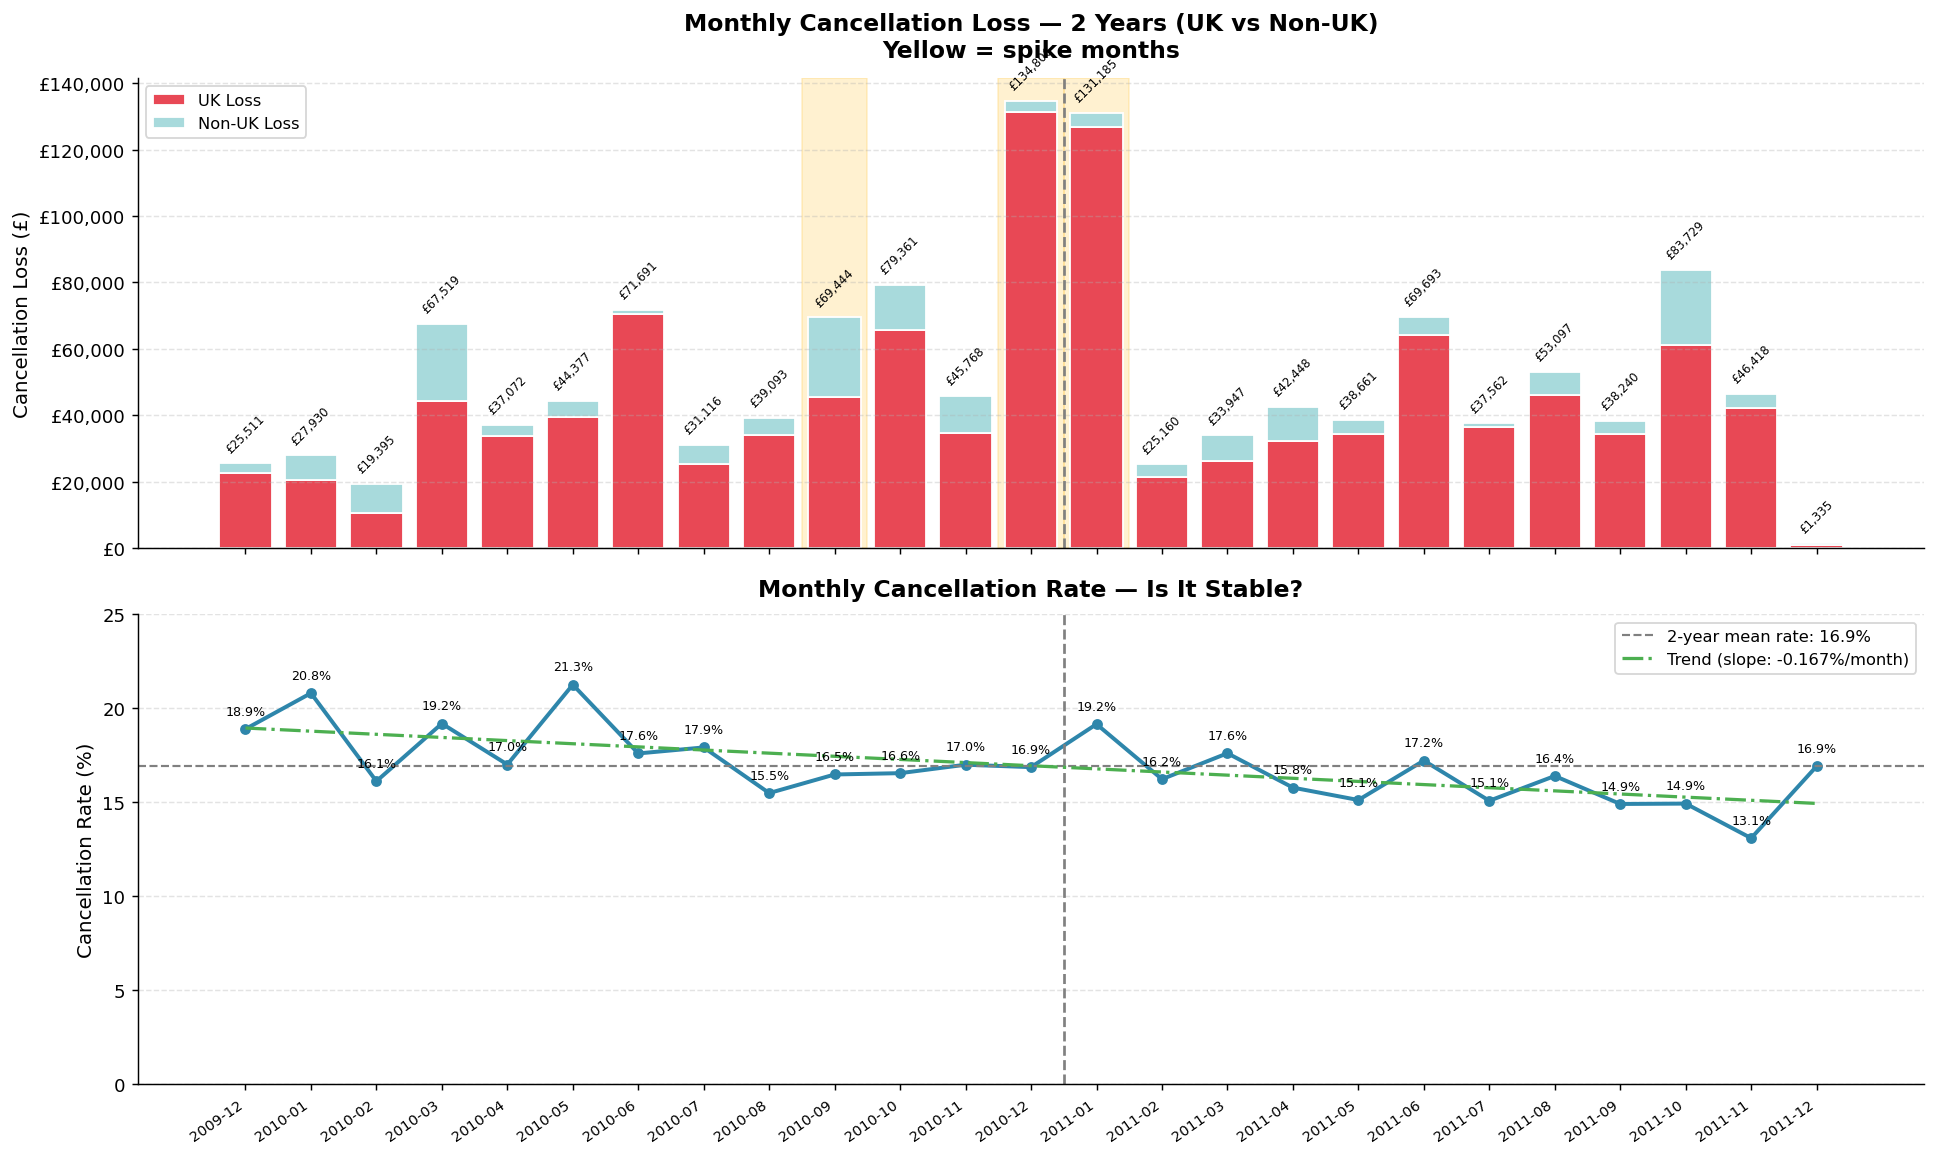

2-year average cancel rate: 16.9% — relatively flat.
Trend slope: -0.167%/month — slight downward trend (improving).
Three notable loss spikes: Sep 2010, Dec 2010, Jan 2011.


In [9]:
m_labels = [str(m) for m in monthly.index]
x = range(len(m_labels))
spike_labels = ['2010-12', '2011-01', '2010-09']
spike_idxs   = [i for i, m in enumerate(m_labels) if m in spike_labels]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax1.bar(x, monthly['UK_Loss'].fillna(0),    color=C_RED,  label='UK Loss',     edgecolor='white')
ax1.bar(x, monthly['NonUK_Loss'].fillna(0), color=C_TEAL, label='Non-UK Loss',
        bottom=monthly['UK_Loss'].fillna(0), edgecolor='white')
for i, row in enumerate(monthly.itertuples()):
    ax1.text(i, row.Cancel_Loss_GBP + 2500, f'£{row.Cancel_Loss_GBP:,.0f}',
             ha='center', va='bottom', fontsize=6.5, rotation=45)
for si in spike_idxs:
    ax1.axvspan(si - 0.5, si + 0.5, color=C_YELLOW, alpha=0.3, zorder=0)
year_boundary = m_labels.index('2011-01')
ax1.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Monthly Cancellation Loss — 2 Years (UK vs Non-UK)\nYellow = spike months', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.35)

ax2.plot(x, monthly['Cancel_Rate_Pct'], color=C_BLUE, marker='o', linewidth=2.2, markersize=5)
for i, v in enumerate(monthly['Cancel_Rate_Pct']):
    ax2.annotate(f'{v:.1f}%', (i, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7)
mean_rate = monthly['Cancel_Rate_Pct'].mean()
ax2.axhline(y=mean_rate, color='grey', linestyle='--', linewidth=1.2,
            label=f'2-year mean rate: {mean_rate:.1f}%')
ax2.axvline(x=year_boundary - 0.5, color='grey', linestyle='--', linewidth=1.5)
z = np.polyfit(list(x), monthly['Cancel_Rate_Pct'], 1)
p_trend = np.poly1d(z)
ax2.plot(x, p_trend(list(x)), color=C_GREEN, linestyle='-.', linewidth=1.8,
         label=f'Trend (slope: {z[0]:+.3f}%/month)')
ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Monthly Cancellation Rate — Is It Stable?', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(m_labels, rotation=35, ha='right', fontsize=8)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.35)
ax2.set_ylim(0, 25)
plt.tight_layout()
plt.savefig('chart5_monthly_2yr.png', bbox_inches='tight')
plt.show()

print(f'2-year average cancel rate: {mean_rate:.1f}% — relatively flat.')
print(f'Trend slope: {z[0]:+.3f}%/month — slight downward trend (improving).')
print('Three notable loss spikes: Sep 2010, Dec 2010, Jan 2011.')

### 3.4 Quarterly Seasonal Pattern

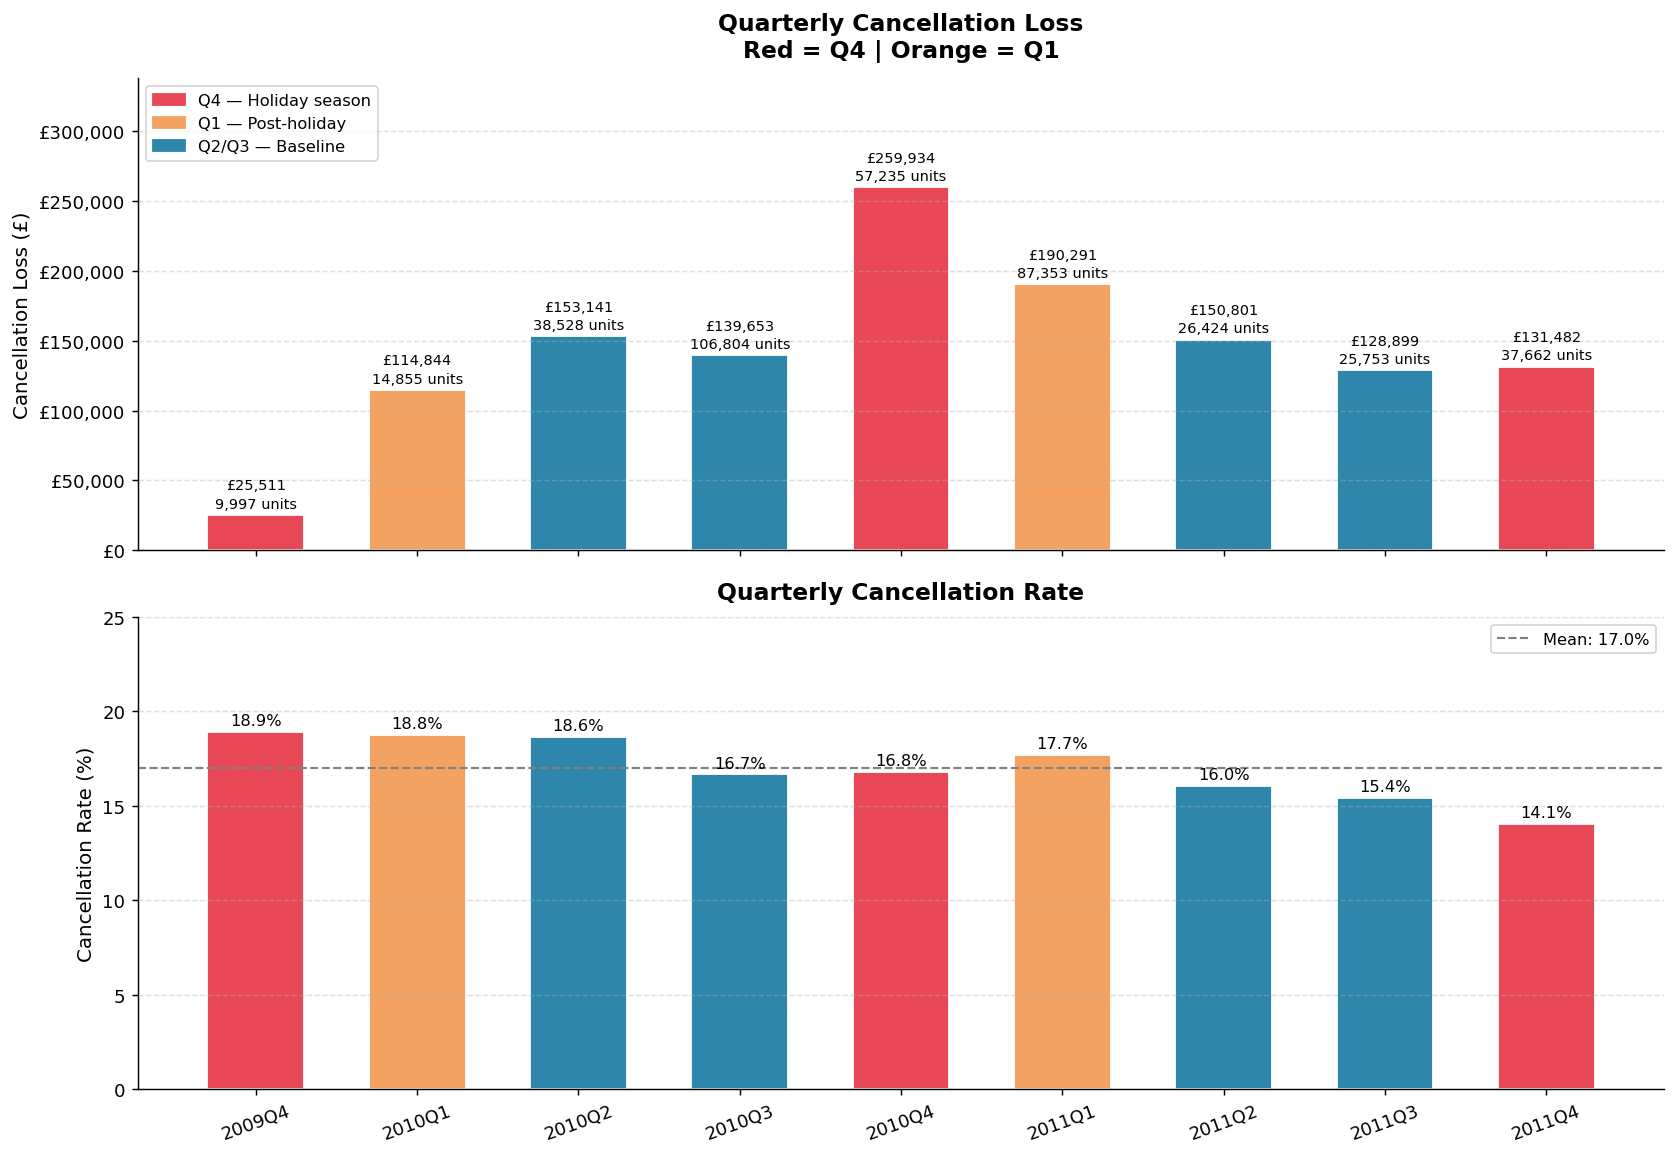

Average Q4 loss: £138,976 vs Q2/Q3 baseline: £143,123
Q4 risk is real but improving year over year.


In [10]:
q_labels   = [str(q) for q in quarterly.index]
bar_colors = []
for q in q_labels:
    if 'Q4' in q:   bar_colors.append(C_RED)
    elif 'Q1' in q: bar_colors.append(C_ORANGE)
    else:           bar_colors.append(C_BLUE)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
bars = ax1.bar(q_labels, quarterly['Cancel_Loss_GBP'], color=bar_colors, edgecolor='white', width=0.6)
for bar, loss, units in zip(bars, quarterly['Cancel_Loss_GBP'], quarterly['Cancel_Units']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'£{loss:,.0f}\n{units:,.0f} units', ha='center', va='bottom', fontsize=8, linespacing=1.4)
ax1.set_ylabel('Cancellation Loss (£)')
ax1.set_title('Quarterly Cancellation Loss\nRed = Q4 | Orange = Q1', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_ylim(0, quarterly['Cancel_Loss_GBP'].max() * 1.3)
legend_q = [
    mpatches.Patch(color=C_RED,    label='Q4 — Holiday season'),
    mpatches.Patch(color=C_ORANGE, label='Q1 — Post-holiday'),
    mpatches.Patch(color=C_BLUE,   label='Q2/Q3 — Baseline')
]
ax1.legend(handles=legend_q, fontsize=9, loc='upper left')
ax2.bar(q_labels, quarterly['Cancel_Rate_Pct'], color=bar_colors, edgecolor='white', width=0.6)
for i, v in enumerate(quarterly['Cancel_Rate_Pct']):
    ax2.text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax2.axhline(y=quarterly['Cancel_Rate_Pct'].mean(), color='grey', linestyle='--', linewidth=1.2,
            label=f'Mean: {quarterly["Cancel_Rate_Pct"].mean():.1f}%')
ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Quarterly Cancellation Rate', pad=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_ylim(0, 25)
ax2.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('chart6_quarterly.png', bbox_inches='tight')
plt.show()

q4_avg   = quarterly[quarterly.index.astype(str).str.contains('Q4')]['Cancel_Loss_GBP'].mean()
q2q3_avg = quarterly[quarterly.index.astype(str).str.contains('Q[23]')]['Cancel_Loss_GBP'].mean()
print(f'Average Q4 loss: £{q4_avg:,.0f} vs Q2/Q3 baseline: £{q2q3_avg:,.0f}')
print('Q4 risk is real but improving year over year.')

### 3.5 Spike Month Products

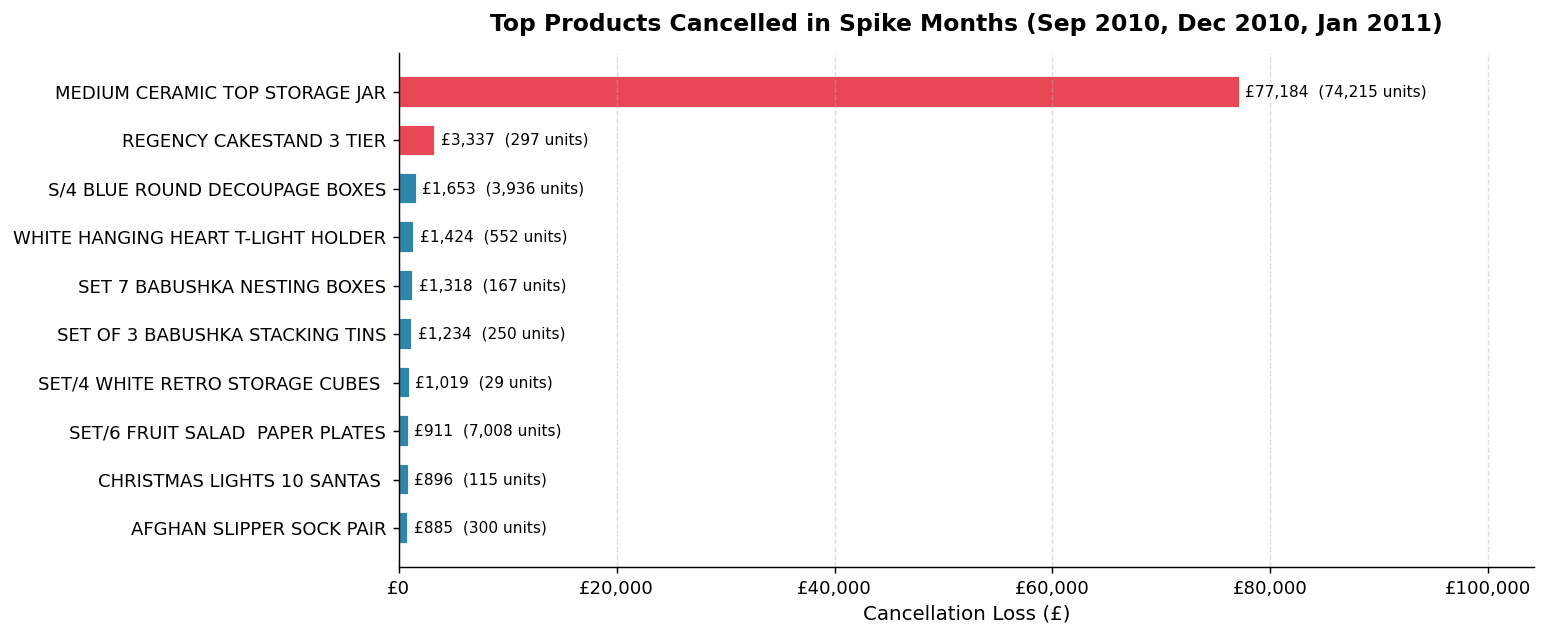

Top SKU: MEDIUM CERAMIC TOP STORAGE JAR — 74,215 units | £77,184
Losses concentrated in 1–2 SKUs — consistent with a bulk B2B event.
→ Handoff to Okah: Is this SKU problematic outside spike months?
→ Handoff to Renato: How many Customer IDs are behind these cancellations?


In [11]:
spike_months = ['2010-09', '2010-12', '2011-01']
spike_df = df[
    (df['Cancelled']) &
    (df['Month'].astype(str).isin(spike_months))
].copy()

exclude_terms = ['AMAZON FEE', 'Manual', 'CRUK', 'Bank Charges', 'Adjust bad debt', 'Discount', 'nan', 'POST']
spike_products = (spike_df
                  .groupby('Description')
                  .agg(
                      Units_Cancelled = ('Quantity', lambda x: x.abs().sum()),
                      Loss_GBP        = ('Loss',     'sum'),
                      Num_Invoices    = ('Invoice',  'nunique')
                  )
                  .sort_values('Loss_GBP', ascending=False))

spike_clean = spike_products[
    ~spike_products.index.str.contains('|'.join(exclude_terms), case=False, na=False)
].head(10).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [C_RED if i < 2 else C_BLUE for i in range(len(spike_clean))]
bars = ax.barh(spike_clean.index[::-1], spike_clean['Loss_GBP'][::-1],
               color=colors[::-1], edgecolor='white', height=0.65)
for bar, units in zip(bars, spike_clean['Units_Cancelled'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{bar.get_width():,.0f}  ({units:,.0f} units)', va='center', fontsize=8.5)
ax.set_xlabel('Cancellation Loss (£)')
ax.set_title('Top Products Cancelled in Spike Months (Sep 2010, Dec 2010, Jan 2011)', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_xlim(0, spike_clean['Loss_GBP'].max() * 1.35)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart8_spike_products.png', bbox_inches='tight')
plt.show()

print(f'Top SKU: {spike_clean.index[0]} — {spike_clean["Units_Cancelled"].iloc[0]:,.0f} units | £{spike_clean["Loss_GBP"].iloc[0]:,.0f}')
print('Losses concentrated in 1–2 SKUs — consistent with a bulk B2B event.')
print('→ Handoff to Okah: Is this SKU problematic outside spike months?')
print('→ Handoff to Renato: How many Customer IDs are behind these cancellations?')

---
## Geographic & Temporal Analysis — Summary Insight

The UK represents 85.2% of all cancellation losses — an extreme Pareto result. Germany and EIRE show higher cancellation *rates* than the UK despite lower volumes. Cancellation behavior is mostly consistent across months; loss spikes in Sep 2010, Dec 2010, and Jan 2011 are volume-driven events, not rate-driven. A positive year-over-year trend shows improvement across all metrics from 2010 to 2011.

---
# Section 2: Customer Analysis
**Section Owner:** Renato Silva

**Three key questions this section answers:**
1. What share of customers accounts for the majority of return volume?
2. Do high-return customers show distinct purchasing behavior, such as higher order frequency or larger basket sizes?
3. Is there a correlation between purchase frequency and return rate?

---

## Question 1: What share of customers accounts for the majority of return value?

In [12]:
# ── Filter: Top 6 countries covering 95% of cancellation loss ─────────────────
TOP6_COUNTRIES = ['United Kingdom', 'EIRE', 'France', 'Norway', 'Spain', 'Germany']

df_top6_cancelled = df[
    (df['Is_Return'] == True) &
    (df['Country'].isin(TOP6_COUNTRIES))
].copy()

print(f'Total cancelled rows (top 6 countries) : {len(df_top6_cancelled):,}')
print(f'Countries included                      : {sorted(df_top6_cancelled["Country"].unique())}')
print(f'Date range                              : {df_top6_cancelled["InvoiceDate"].min().date()} → {df_top6_cancelled["InvoiceDate"].max().date()}')
print()

unique_customers        = df_top6_cancelled[cid_col].nunique()
unique_customers_no_nan = df_top6_cancelled[cid_col].dropna().nunique()
print(f'Unique customers (incl. NaN)  : {unique_customers:,}')
print(f'Unique customers (excl. NaN)  : {unique_customers_no_nan:,}')
print()

country_summary = (df_top6_cancelled
                   .groupby('Country')
                   .agg(
                       Cancelled_Rows     = ('Invoice',  'count'),
                       Unique_Customers   = (cid_col,   'nunique'),
                       Cancelled_Invoices = ('Invoice',  'nunique'),
                       Total_Loss_GBP     = ('Loss',     'sum')
                   )
                   .sort_values('Total_Loss_GBP', ascending=False)
                   .round(2))
print(country_summary.to_string())

Total cancelled rows (top 6 countries) : 18,010
Countries included                      : ['EIRE', 'France', 'Germany', 'Norway', 'Spain', 'United Kingdom']
Date range                              : 2009-12-01 → 2011-12-04

Unique customers (incl. NaN)  : 2,423
Unique customers (excl. NaN)  : 2,423

                Cancelled_Rows  Unique_Customers  Cancelled_Invoices  Total_Loss_GBP
Country                                                                             
United Kingdom           16149              2292                7045      1104222.13
EIRE                       508                 3                 178        48357.55
France                     369                42                 113        28228.60
Norway                      18                 4                   8        20866.59
Spain                       81                16                  29        16854.27
Germany                    885                66                 290        12516.40


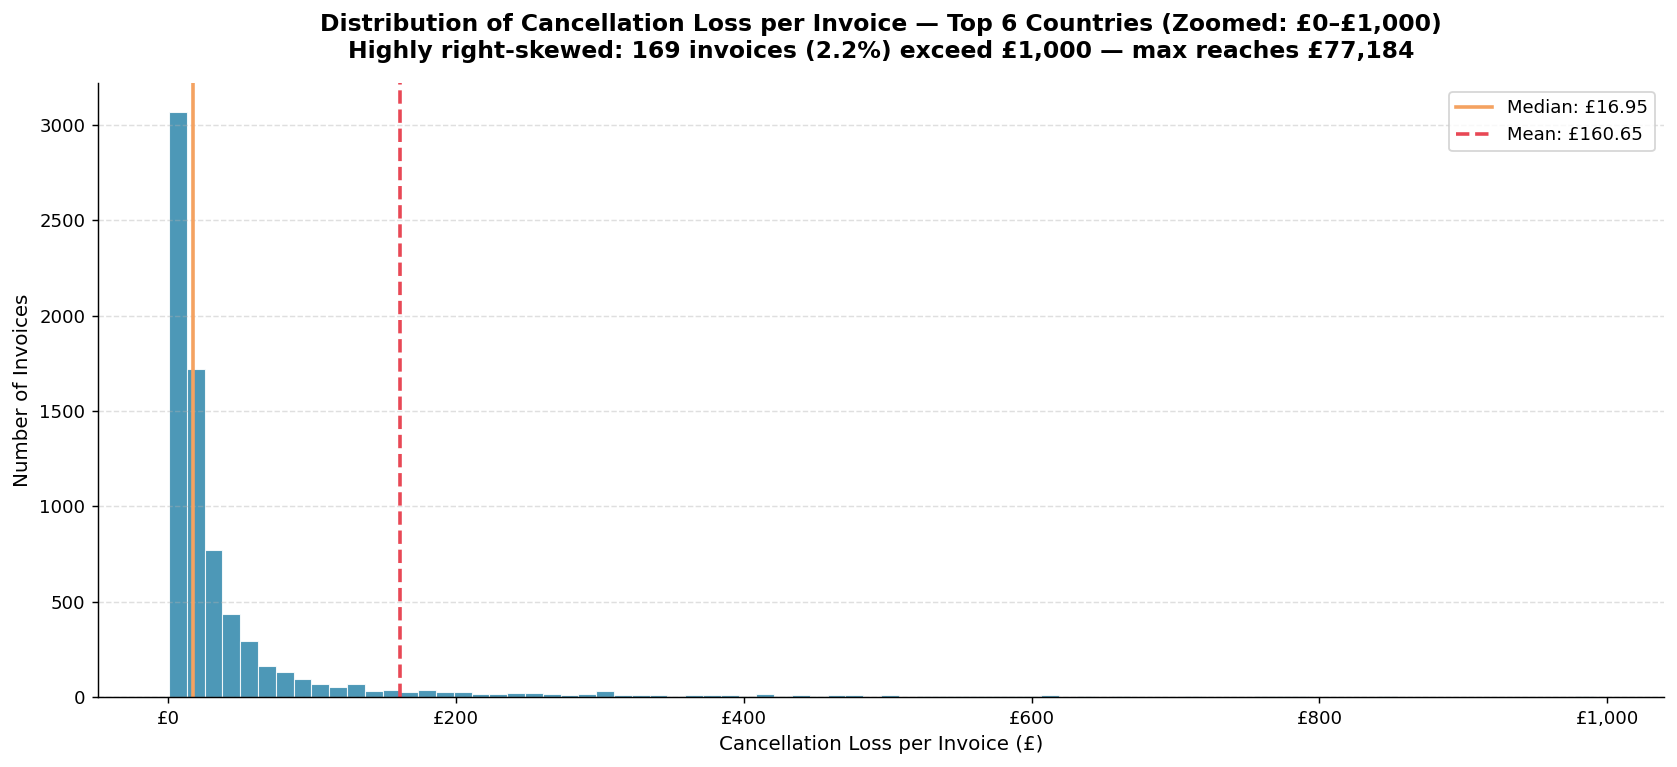

Invoices within £0–£1,000 : 7,494 (97.8%)
Invoices above £1,000     : 169 (2.2%)
Max invoice loss          : £77,183.60
Median                    : £16.95
Mean                      : £160.65


In [13]:
# ── Loss per cancelled invoice — Zoomed histogram £0–£1,000 ──────────────────
invoice_loss = (df_top6_cancelled
                .groupby('Invoice')['Loss']
                .sum()
                .reset_index()
                .rename(columns={'Loss': 'Invoice_Loss'}))

invoice_loss_filtered = invoice_loss[invoice_loss['Invoice_Loss'] <= 1000]
excluded     = len(invoice_loss) - len(invoice_loss_filtered)
excluded_pct = excluded / len(invoice_loss) * 100
max_loss     = invoice_loss['Invoice_Loss'].max()

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(invoice_loss_filtered['Invoice_Loss'], bins=80, color=C_BLUE,
        edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(invoice_loss['Invoice_Loss'].median(), color=C_ORANGE, linewidth=2,
           label=f'Median: £{invoice_loss["Invoice_Loss"].median():,.2f}')
ax.axvline(invoice_loss['Invoice_Loss'].mean(), color=C_RED, linewidth=2, linestyle='--',
           label=f'Mean: £{invoice_loss["Invoice_Loss"].mean():,.2f}')
ax.set_xlabel('Cancellation Loss per Invoice (£)')
ax.set_ylabel('Number of Invoices')
ax.set_title(
    'Distribution of Cancellation Loss per Invoice — Top 6 Countries (Zoomed: £0–£1,000)\n'
    f'Highly right-skewed: {excluded:,} invoices ({excluded_pct:.1f}%) exceed £1,000 — max reaches £{max_loss:,.0f}',
    pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_invoice_loss_distribution_zoomed.png', bbox_inches='tight')
plt.show()

print(f'Invoices within £0–£1,000 : {len(invoice_loss_filtered):,} ({100-excluded_pct:.1f}%)')
print(f'Invoices above £1,000     : {excluded:,} ({excluded_pct:.1f}%)')
print(f'Max invoice loss          : £{max_loss:,.2f}')
print(f'Median                    : £{invoice_loss["Invoice_Loss"].median():,.2f}')
print(f'Mean                      : £{invoice_loss["Invoice_Loss"].mean():,.2f}')

In [14]:
# ── Loss per customer per country ─────────────────────────────────────────────
customer_country_loss = (df_top6_cancelled
                         .groupby(['Country', cid_col])['Loss']
                         .sum()
                         .reset_index()
                         .rename(columns={'Loss': 'Total_Loss_GBP'}))

country_stats = (customer_country_loss
                 .groupby('Country')['Total_Loss_GBP']
                 .agg(
                     Num_Customers = 'count',
                     Min           = 'min',
                     Q25           = lambda x: x.quantile(0.25),
                     Median        = 'median',
                     Mean          = 'mean',
                     Q75           = lambda x: x.quantile(0.75),
                     Max           = 'max',
                     Total_Loss    = 'sum'
                 )
                 .round(2)
                 .sort_values('Total_Loss', ascending=False))

print('Customer Loss Distribution by Country (£)')
print('=' * 80)
print(country_stats.to_string())

Customer Loss Distribution by Country (£)
                Num_Customers    Min      Q25    Median      Mean       Q75       Max  Total_Loss
Country                                                                                          
United Kingdom           2292   0.42    15.95     39.88    314.53    117.49  77620.14   720901.80
EIRE                        3  23.70  8702.69  17381.68  14191.60  21275.55  25169.42    42574.80
France                     42   3.90    15.49     86.40    672.11    237.16  12829.34    28228.60
Norway                      4  41.35   124.64    556.52   5216.65   5648.52  19712.21    20866.59
Spain                      16   5.77    19.25     52.62   1053.39    377.24  12387.07    16854.27
Germany                    66   4.95    31.67     61.53    189.64    196.38   1821.98    12516.40


In [16]:
# ── Pareto analysis per country ───────────────────────────────────────────────
pareto_results = []

for country in TOP6_COUNTRIES:
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total = country_df['Total_Loss_GBP'].sum()
    country_df['Loss_Share_Pct']      = (country_df['Total_Loss_GBP'] / total * 100).round(2)
    country_df['Cumulative_Loss_Pct'] = country_df['Loss_Share_Pct'].cumsum().round(2)
    pareto_results.append(country_df)

pareto_df = pd.concat(pareto_results)

for country in TOP6_COUNTRIES:
    subset     = pareto_df[pareto_df['Country'] == country].copy()
    at_80      = subset[subset['Cumulative_Loss_Pct'] <= 80]
    first_over = subset[subset['Cumulative_Loss_Pct'] > 80].head(1)
    top80      = pd.concat([at_80, first_over]).copy()
    top80[cid_col] = top80[cid_col].apply(
        lambda x: f'Customer {int(x)}' if not pd.isna(x) else 'Unknown')
    print(f'{"=" * 60}')
    print(f'{country} — {len(subset):,} customers | Total Loss: £{subset["Total_Loss_GBP"].sum():,.2f}')
    print(f'Customers needed to reach 80%: {len(top80)}')
    print(f'{"=" * 60}')
    print(top80[[cid_col, 'Total_Loss_GBP', 'Loss_Share_Pct', 'Cumulative_Loss_Pct']].to_string(index=False))
    print()

United Kingdom — 2,292 customers | Total Loss: £720,901.80
Customers needed to reach 80%: 190
   Customer ID  Total_Loss_GBP  Loss_Share_Pct  Cumulative_Loss_Pct
Customer 12346        77620.14           10.77                10.77
Customer 15098        39267.00            5.45                16.22
Customer 14063        26477.40            3.67                19.89
Customer 17399        25111.09            3.48                23.37
Customer 15749        22998.40            3.19                26.56
Customer 16029        21925.44            3.04                29.60
Customer 12918        21907.00            3.04                32.64
Customer 12931        20923.37            2.90                35.54
Customer 17949        19529.99            2.71                38.25
Customer 17450        12370.50            1.72                39.97
Customer 16754        10941.89            1.52                41.49
Customer 18102         9378.01            1.30                42.79
Customer 15413        

In [17]:
# ── Pareto customer lists ─────────────────────────────────────────────────────
def get_pareto_customers(country):
    subset     = pareto_df[pareto_df['Country'] == country].copy()
    at_80      = subset[subset['Cumulative_Loss_Pct'] <= 80]
    first_over = subset[subset['Cumulative_Loss_Pct'] > 80].head(1)
    return pd.concat([at_80, first_over])[cid_col].tolist()

uk_customers      = get_pareto_customers('United Kingdom')
germany_customers = get_pareto_customers('Germany')

print(f'UK Pareto accounts      : {len(uk_customers)}')
print(f'Germany Pareto accounts : {len(germany_customers)}')

UK Pareto accounts      : 190
Germany Pareto accounts : 19


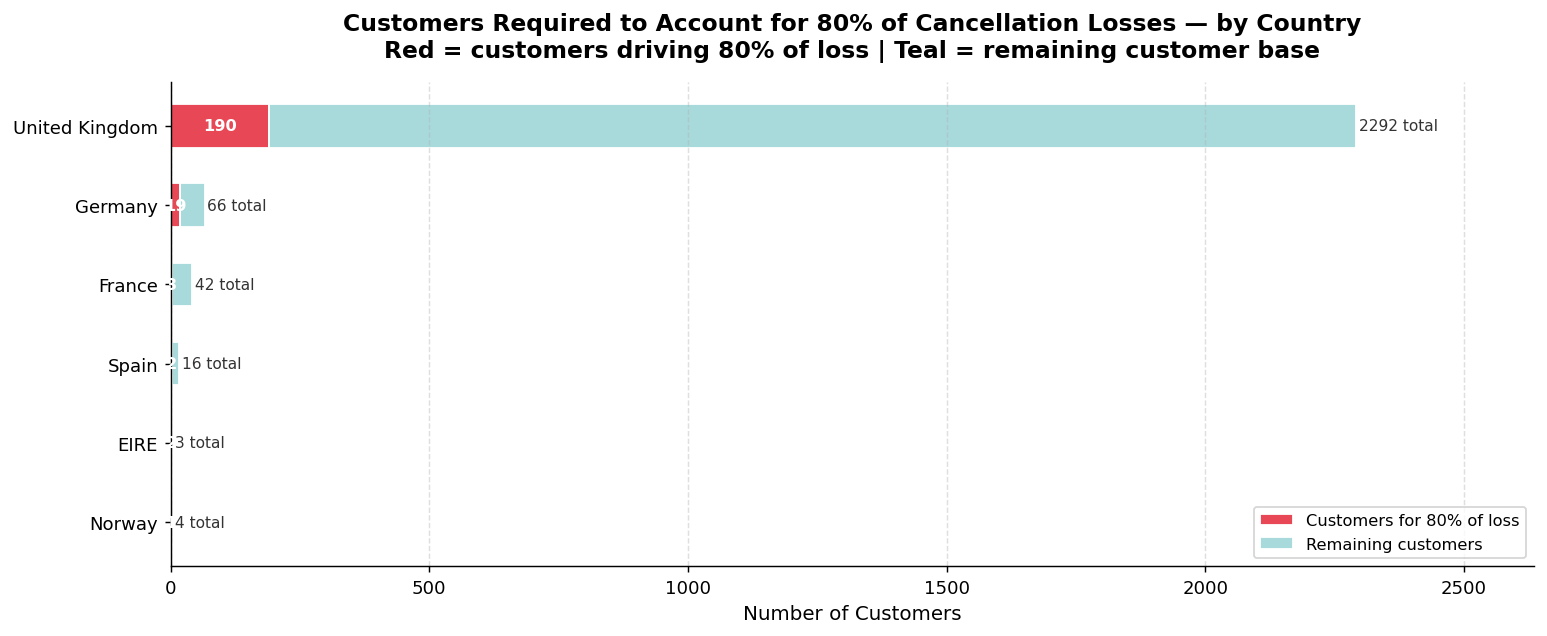

In [18]:
# ── Chart 1: Customers needed to reach 80% vs total ──────────────────────────
customers_for_80 = {}
total_customers  = {}

for country in TOP6_COUNTRIES:
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total      = country_df['Total_Loss_GBP'].sum()
    country_df['Cumulative_Loss_Pct'] = (country_df['Total_Loss_GBP'] / total * 100).cumsum()
    at_80 = country_df[country_df['Cumulative_Loss_Pct'] <= 80]
    customers_for_80[country] = len(at_80) + 1
    total_customers[country]  = len(country_df)

summary_df = pd.DataFrame({
    'Country':         TOP6_COUNTRIES,
    'For_80_Pct':      [customers_for_80[c] for c in TOP6_COUNTRIES],
    'Total_Customers': [total_customers[c]  for c in TOP6_COUNTRIES]
}).sort_values('For_80_Pct', ascending=True)
summary_df['Others'] = summary_df['Total_Customers'] - summary_df['For_80_Pct']

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.barh(summary_df['Country'], summary_df['For_80_Pct'],
                color=C_RED, edgecolor='white', label='Customers for 80% of loss', height=0.55)
bars2 = ax.barh(summary_df['Country'], summary_df['Others'],
                left=summary_df['For_80_Pct'],
                color=C_TEAL, edgecolor='white', label='Remaining customers', height=0.55)
for bar, val in zip(bars1, summary_df['For_80_Pct']):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'{val}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
for bar, total in zip(bars2, summary_df['Total_Customers']):
    ax.text(bar.get_x() + bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{total} total', ha='left', va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Number of Customers')
ax.set_title('Customers Required to Account for 80% of Cancellation Losses — by Country\n'
             'Red = customers driving 80% of loss | Teal = remaining customer base', pad=14)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(0, summary_df['Total_Customers'].max() * 1.15)
plt.tight_layout()
plt.savefig('chart_customers_80pct.png', bbox_inches='tight')
plt.show()

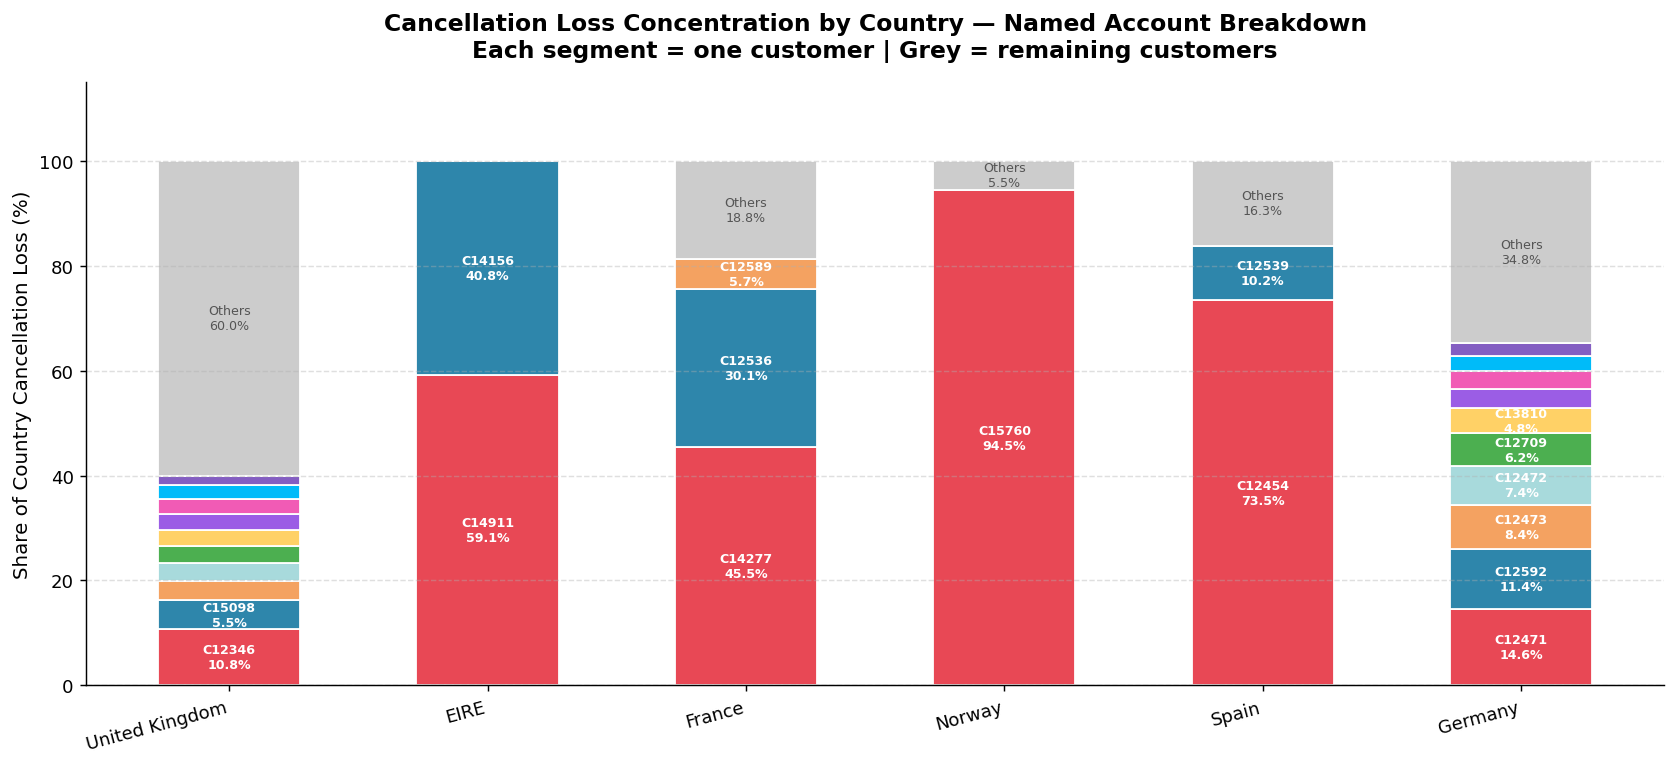

In [19]:
# ── Chart 2: Stacked loss share per country ───────────────────────────────────
COLORS_PALETTE = [C_RED, C_BLUE, C_ORANGE, C_TEAL, C_GREEN,
                  C_YELLOW, '#9B5DE5', '#F15BB5', '#00BBF9', '#845EC2']
TOP_N = {'United Kingdom': 10, 'EIRE': 2, 'France': 3, 'Norway': 1, 'Spain': 2, 'Germany': 10}

fig, ax = plt.subplots(figsize=(13, 6))
bar_positions = range(len(TOP6_COUNTRIES))
bottom        = [0] * len(TOP6_COUNTRIES)

for i, country in enumerate(TOP6_COUNTRIES):
    country_df = customer_country_loss[customer_country_loss['Country'] == country].copy()
    country_df = country_df.sort_values('Total_Loss_GBP', ascending=False)
    total      = country_df['Total_Loss_GBP'].sum()
    country_df['Loss_Share_Pct'] = (country_df['Total_Loss_GBP'] / total * 100).round(2)
    top_n  = TOP_N[country]
    top_df = country_df.head(top_n)
    others = 100 - top_df['Loss_Share_Pct'].sum()
    for j, (_, row) in enumerate(top_df.iterrows()):
        color = COLORS_PALETTE[j % len(COLORS_PALETTE)]
        ax.bar(i, row['Loss_Share_Pct'], bottom=bottom[i], color=color, edgecolor='white', width=0.55)
        if row['Loss_Share_Pct'] > 4:
            ax.text(i, bottom[i] + row['Loss_Share_Pct'] / 2,
                    f'C{int(row[cid_col])}\n{row["Loss_Share_Pct"]:.1f}%',
                    ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        bottom[i] += row['Loss_Share_Pct']
    if others > 0:
        ax.bar(i, others, bottom=bottom[i], color='#CCCCCC', edgecolor='white', width=0.55)
        if others > 4:
            ax.text(i, bottom[i] + others / 2, f'Others\n{others:.1f}%',
                    ha='center', va='center', fontsize=7, color='#555')
        bottom[i] += others

ax.set_xticks(list(bar_positions))
ax.set_xticklabels(TOP6_COUNTRIES, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Share of Country Cancellation Loss (%)')
ax.set_ylim(0, 115)
ax.set_title('Cancellation Loss Concentration by Country — Named Account Breakdown\n'
             'Each segment = one customer | Grey = remaining customers', pad=14)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart_loss_concentration_stacked.png', bbox_inches='tight')
plt.show()

**Question 1 Answer:**

**EIRE — £42,574.80 | 3 customers**

Two accounts explain virtually all of EIRE's cancellation losses. Customer 14911 accounts for 59.12% (£25,169) and Customer 14156 for a further 40.83% (£17,381). Resolving these two accounts eliminates the problem entirely.

---

**Norway — £20,866.59 | 4 customers**

Customer 15760 is responsible for £19,712 — 94.47% of Norway's total cancellation loss. The remaining three customers are negligible. Note: the majority of these losses are StockCode M manual entries — real losses but with no product detail attached.

---

**France — £28,228.60 | 42 customers**

Three accounts drive 81.20% of French losses. Customer 14277 leads at 45.45% (£12,829), followed by Customer 12536 at 30.09% (£8,495), with Customer 12589 contributing 5.66% (£1,598).

---

**Spain — £16,854.27 | 16 customers**

Customer 12454 alone represents 73.50% of Spain's total losses at £12,387. Customer 12539 adds a further 10.18%.

---

**Germany — £12,516.40 | 66 customers**

Germany has no dominant account. The largest customer represents only 14.56% of losses, and 19 customers are required to reach the 80% threshold. Customer segmentation is recommended to identify shared behavioral patterns.

---

**United Kingdom — £720,901.80 | 2,292 customers**

The UK represents 85.2% of total cancellation losses. Customer 12346 (£77,620, 10.77%) and Customer 15098 (£39,267, 5.45%) merit individual review, but reaching 80% requires 190 customers. K-Means clustering on the full 190 Pareto accounts is strongly recommended.

---
## Question 2: Do high-return customers show distinct purchasing behavior?

### RFMR Score Scale — 1 to 5 (Quintile-based)

Each dimension is split into 5 equal groups (20% of accounts each). Score 5 = highest risk, score 1 = lowest risk. Scores are calculated independently within each country group.

| Score | Percentile | Meaning |
|:---|:---|:---|
| 5 | Top 20% | Highest risk |
| 4 | 60th – 80th | Above average |
| 3 | 40th – 60th | Middle |
| 2 | 20th – 40th | Below average |
| 1 | Bottom 20% | Lowest risk |

> **R (Recency):** Inverted — score 5 = cancelled most recently = highest active risk.  
> **F:** Total order frequency across all invoices (not just cancellations).  
> **M:** Total gross purchases in £.  
> **Re:** Total cancellation loss in £ (not a ratio).

In [20]:
# ── RFMR: Build from full df ──────────────────────────────────────────────────
DATASET_END = df['InvoiceDate'].max()

total_frequency = (df[df['Is_Return'] == False]
                   .groupby(cid_col)['Invoice']
                   .nunique()
                   .reset_index()
                   .rename(columns={'Invoice': 'F_TotalOrders'}))

gross = (df[df['Is_Return'] == False]
         .assign(GrossValue=lambda x: x['Quantity'] * x['Price'])
         .groupby(cid_col)['GrossValue']
         .sum()
         .reset_index()
         .rename(columns={'GrossValue': 'M_GrossPurchases'}))

cancel_rfmr = (df_top6_cancelled
               .groupby(cid_col)
               .agg(
                   R_LastCancel  = ('InvoiceDate', 'max'),
                   Re_CancelLoss = ('Loss',        'sum')
               )
               .reset_index())

cancel_rfmr['R_Recency'] = (DATASET_END - cancel_rfmr['R_LastCancel']).dt.days

rfmr = (cancel_rfmr
        .merge(total_frequency, on=cid_col, how='left')
        .merge(gross,           on=cid_col, how='left'))

rfmr['F_TotalOrders']    = rfmr['F_TotalOrders'].fillna(0)
rfmr['M_GrossPurchases'] = rfmr['M_GrossPurchases'].fillna(0)
rfmr['Country']          = (df_top6_cancelled
                             .groupby(cid_col)['Country']
                             .first()
                             .reset_index()['Country'])

display_cols = [cid_col, 'Country', 'R_Recency', 'F_TotalOrders',
                'M_GrossPurchases', 'Re_CancelLoss']

rfmr_uk      = rfmr[rfmr[cid_col].isin(uk_customers)].copy()
rfmr_germany = rfmr[rfmr[cid_col].isin(germany_customers)].copy()

print(f'RFMR built: {len(rfmr):,} customers')
print(f'UK group     : {len(rfmr_uk)} accounts')
print(f'Germany group: {len(rfmr_germany)} accounts')

RFMR built: 2,423 customers
UK group     : 190 accounts
Germany group: 19 accounts


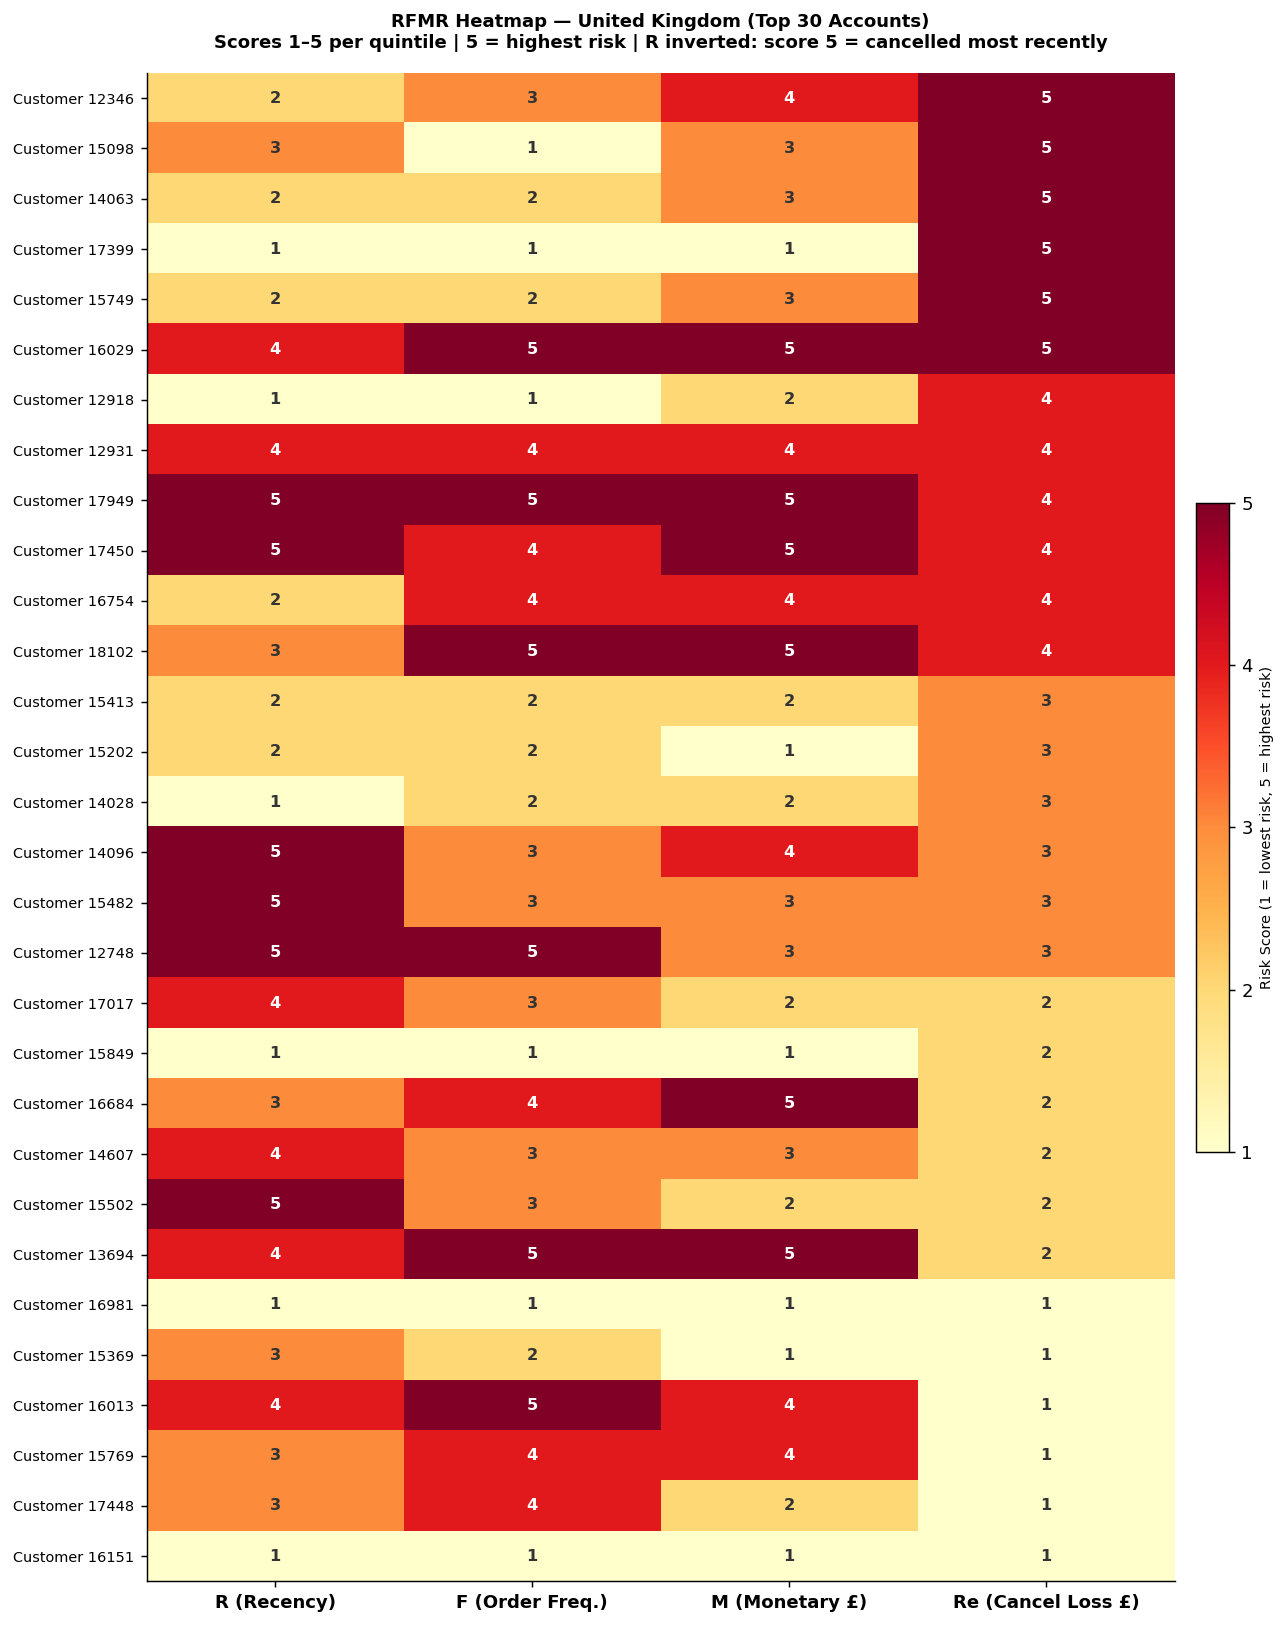

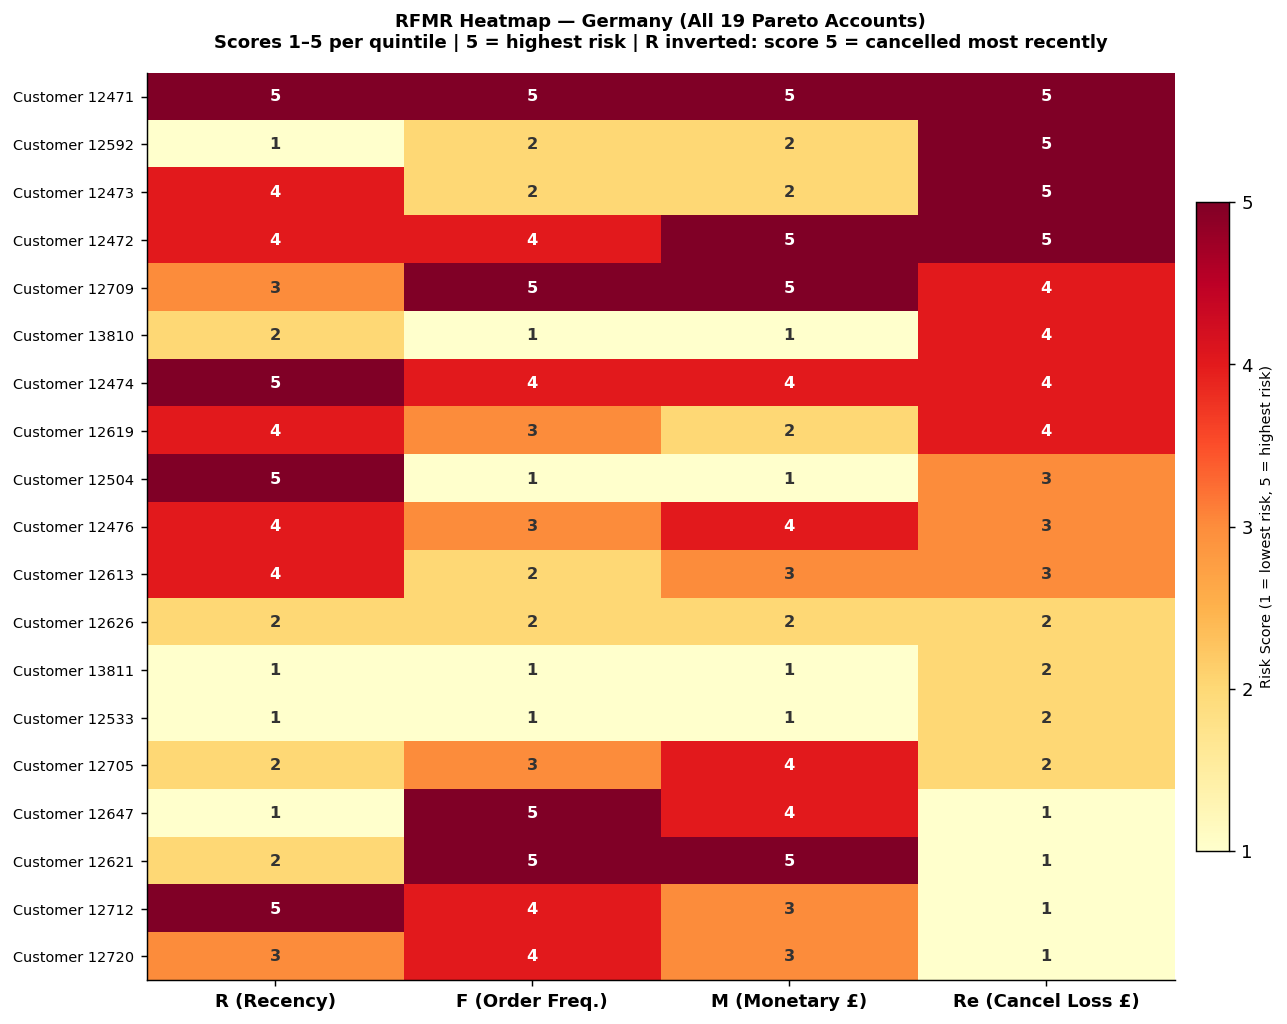

In [21]:
# ── Scoring function (1–5 quintiles) ─────────────────────────────────────────
def score_rfmr(group_df, top_n=None):
    df_plot = group_df[display_cols].copy()
    df_plot = df_plot.sort_values('Re_CancelLoss', ascending=False)
    if top_n:
        df_plot = df_plot.head(top_n)
    df_plot['Re_CancelLoss'] = df_plot['Re_CancelLoss'].fillna(0)
    df_plot['Label'] = df_plot[cid_col].apply(
        lambda x: f'Customer {int(x)}' if not pd.isna(x) else 'Unknown')
    df_plot = df_plot.set_index('Label')
    scored = pd.DataFrame(index=df_plot.index)
    scored['R (Recency)']        = pd.qcut(df_plot['R_Recency'],
                                            q=5, labels=[5,4,3,2,1]).astype(int)
    scored['F (Order Freq.)']    = pd.qcut(df_plot['F_TotalOrders'].rank(method='first'),
                                            q=5, labels=[1,2,3,4,5]).astype(int)
    scored['M (Monetary £)']     = pd.qcut(df_plot['M_GrossPurchases'].rank(method='first'),
                                            q=5, labels=[1,2,3,4,5]).astype(int)
    scored['Re (Cancel Loss £)'] = pd.qcut(df_plot['Re_CancelLoss'].rank(method='first'),
                                            q=5, labels=[1,2,3,4,5]).astype(int)
    return scored

# ── Heatmap function ──────────────────────────────────────────────────────────
def plot_rfmr_heatmap(scored_df, title):
    n_rows  = len(scored_df)
    fig_h   = max(6, n_rows * 0.42)
    fig, ax = plt.subplots(figsize=(10, fig_h))
    im = ax.imshow(scored_df.values.astype(float),
                   aspect='auto', cmap='YlOrRd', vmin=1, vmax=5)
    ax.set_xticks(range(len(scored_df.columns)))
    ax.set_xticklabels(scored_df.columns, fontsize=10, fontweight='bold')
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(scored_df.index, fontsize=8)
    for i in range(n_rows):
        for j in range(len(scored_df.columns)):
            val   = scored_df.iloc[i, j]
            color = 'white' if val >= 4 else '#333333'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.set_label('Risk Score (1 = lowest risk, 5 = highest risk)', fontsize=8)
    ax.set_title(
        f'{title}\nScores 1–5 per quintile | 5 = highest risk | R inverted: score 5 = cancelled most recently',
        pad=14, fontsize=10)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('/', '').replace('—','').strip() + '.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()

# ── Plot UK top 30 and Germany all 19 ────────────────────────────────────────
plot_rfmr_heatmap(score_rfmr(rfmr_uk, top_n=30),
                  'RFMR Heatmap — United Kingdom (Top 30 Accounts)')

plot_rfmr_heatmap(score_rfmr(rfmr_germany),
                  'RFMR Heatmap — Germany (All 19 Pareto Accounts)')

# Note: EIRE, France, Norway, Spain heatmaps excluded.
# Quintile scoring is not meaningful for groups dominated by 1–2 customers.
# These accounts are fully covered in the Pareto analysis above.

**Question 2 Answer:**

Not uniformly. In the **UK**, high cancellation loss customers are mostly medium-to-large buyers who cancelled once and went quiet — order size, not behavior, is the differentiator. Low recency and low frequency confirm they are not chronic returners.

In **Germany**, two profiles emerge:

- *The One-Time Disengaged Buyer* (R: 4–5, F: 2, M: 2) — recent, low-frequency, low-spending customers who likely cancelled and never came back. Possible product-market fit issue.
- *The High-Value Chronic Canceller* (R: 4–5, F: 4–5, M: 4–5) — frequent, high-spending customers with ongoing cancellation patterns. Suggests operational friction or speculative ordering behavior.

Unlike the UK, Germany's problem is active and current — not historical.

No single behavioral profile defines a high-return customer across both markets. **K-Means clustering on the full 190 UK and 19 Germany Pareto accounts is recommended** as a next step.

---
## Question 3: Is there a correlation between purchase frequency and return rate?

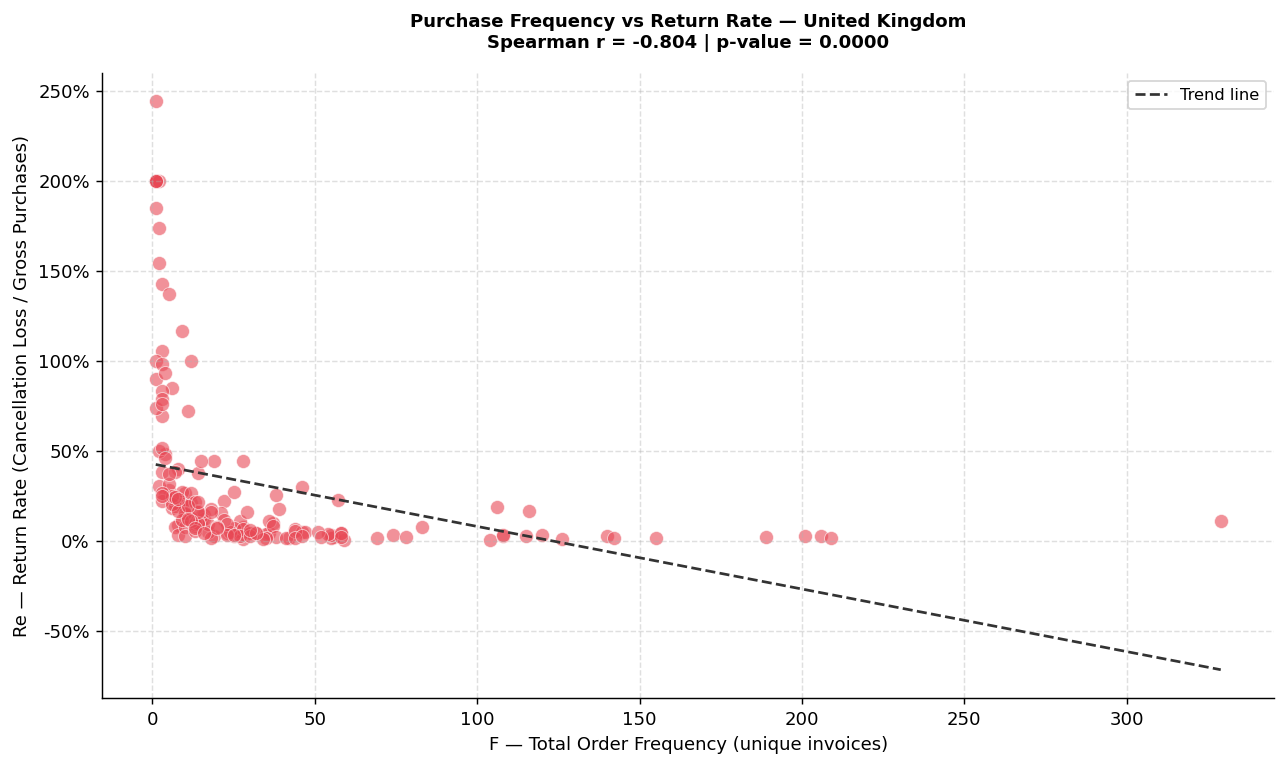

Spearman correlation : -0.804
P-value              : 0.0000
Interpretation       : statistically significant



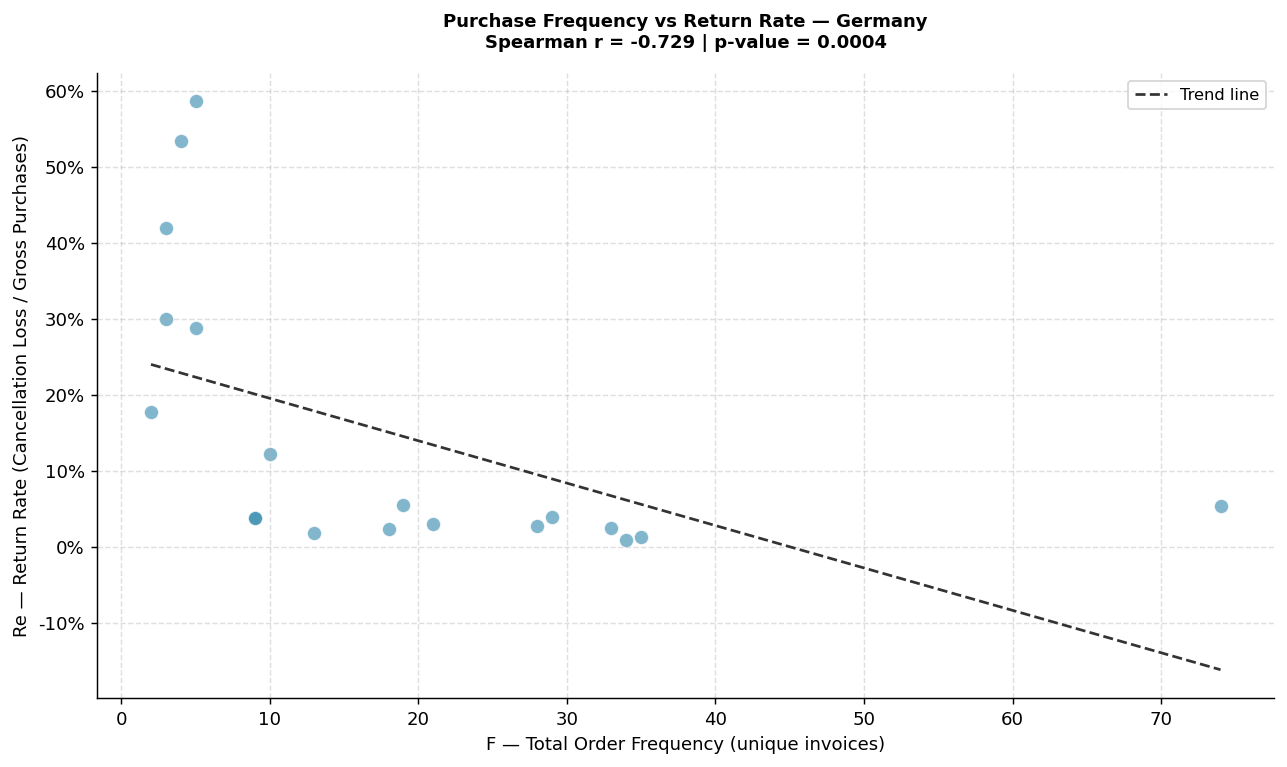

Spearman correlation : -0.729
P-value              : 0.0004
Interpretation       : statistically significant



In [22]:
from scipy.stats import spearmanr

# ── Return rate ratio for correlation ─────────────────────────────────────────
rfmr_corr = rfmr.copy()
rfmr_corr['Re_Ratio'] = (rfmr_corr['Re_CancelLoss'] /
                          rfmr_corr['M_GrossPurchases'].replace(0, float('nan'))).round(4)

rfmr_uk_corr      = rfmr_corr[rfmr_corr[cid_col].isin(uk_customers)].dropna(subset=['Re_Ratio'])
rfmr_germany_corr = rfmr_corr[rfmr_corr[cid_col].isin(germany_customers)].dropna(subset=['Re_Ratio'])

def plot_correlation_scatter(df_plot, title, color):
    x = df_plot['F_TotalOrders']
    y = df_plot['Re_Ratio']
    corr, pvalue = spearmanr(x, y)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, color=color, alpha=0.6, edgecolors='white', linewidths=0.5, s=60)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(sorted(x), p(sorted(x)), color='#333333', linestyle='--', linewidth=1.5, label='Trend line')
    ax.set_xlabel('F — Total Order Frequency (unique invoices)', fontsize=10)
    ax.set_ylabel('Re — Return Rate (Cancellation Loss / Gross Purchases)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(f'{title}\nSpearman r = {corr:.3f} | p-value = {pvalue:.4f}', pad=14, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('—', '').strip() + '.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Spearman correlation : {corr:.3f}')
    print(f'P-value              : {pvalue:.4f}')
    print(f'Interpretation       : {"statistically significant" if pvalue < 0.05 else "not statistically significant"}')
    print()

plot_correlation_scatter(rfmr_uk_corr,
                         'Purchase Frequency vs Return Rate — United Kingdom', C_RED)
plot_correlation_scatter(rfmr_germany_corr,
                         'Purchase Frequency vs Return Rate — Germany', C_BLUE)

**Question 3 Answer:**

Yes, and the direction is **negative**. Customers who order more frequently tend to cancel a smaller proportion of their purchases. The Spearman correlation confirms this relationship is statistically significant.

**L-shaped distribution:** Low-frequency customers show a wide and unpredictable spread of return rates. As frequency increases, return rates converge toward zero and become consistent. Loyalty stabilizes cancellation behavior.

**Return rates above 100%:** A small number of customers show return rates above 100% (~250% max). This is mathematically possible when cancellation losses exceed recorded gross purchases — likely due to timing mismatches or StockCode M manual entries. These are edge cases and do not affect the overall correlation finding.

**In short:** Frequent buyers are lower risk. The danger zone is infrequent buyers whose behavior is unpredictable. Retaining frequent customers reduces both revenue risk and cancellation exposure.

---
# Section 3: Product Analysis
**Section Owner:** Okah Ahone Ebwekoh

**Three key questions this section answers:**
1. Which products have the highest return rates as a share of units sold?
2. Do high-return products share characteristics such as price range or category?
3. Does a Pareto pattern hold — do a small number of products account for most returns?

---

In [24]:
# ── Product-specific filtering ────────────────────────────────────────────────
# This section requires additional cleaning beyond the shared cleaning cell.
# StockCode M (manual adjustments), S, AMAZONFEE, DOT, CRUK, BANK CHARGES
# have no product detail and are excluded from SKU-level analysis only.
# df remains unchanged for geographic and customer sections above.

NON_PRODUCT_EXTRA = ['M', 'S', 'AMAZONFEE', 'DOT', 'CRUK', 'BANK CHARGES']

df_product = df[~df['StockCode'].str.upper().isin(
    [x.upper() for x in NON_PRODUCT_EXTRA])].copy()
df_product = df_product[~df_product['StockCode'].str.upper().str.startswith('ADJUST')].copy()

cancelled_product = df_product[df_product['Cancelled']].copy()

print(f'Total transactions (product-cleaned) : {len(df_product):,}')
print(f'Cancelled rows (product-cleaned)     : {len(cancelled_product):,}')
print(f'Unique products (cancelled)          : {cancelled_product["StockCode"].nunique():,}')
print(f'Total cancellation loss              : £{cancelled_product["Loss"].sum():,.2f}')
print()
print('Note: StockCode M and other non-product codes excluded from this section only.')

Total transactions (product-cleaned) : 1,036,986
Cancelled rows (product-cleaned)     : 18,073
Unique products (cancelled)          : 2,874
Total cancellation loss              : £554,101.88

Note: StockCode M and other non-product codes excluded from this section only.


## 1. Pareto Analysis — Which Products Drive the Most Loss?
> **Q3:** Do a small number of products account for most cancellation losses?

In [25]:
prod = (cancelled_product
        .groupby(['StockCode', 'Description'])
        .agg(
            cancel_units    = ('Quantity',  lambda x: x.abs().sum()),
            cancel_loss     = ('Loss',      'sum'),
            cancel_invoices = ('Invoice',   'nunique')
        )
        .sort_values('cancel_loss', ascending=False)
        .reset_index())

sold = df_product[~df_product['Cancelled']].groupby('StockCode')['Quantity'].sum().rename('sold_units')
prod = prod.merge(sold.reset_index(), on='StockCode', how='left')
prod['return_rate_pct'] = (
    prod['cancel_units'] / (prod['cancel_units'] + prod['sold_units'].fillna(0)) * 100
).round(1)

total_loss_prod         = prod['cancel_loss'].sum()
prod['loss_share_pct']  = (prod['cancel_loss'] / total_loss_prod * 100).round(2)
prod['cumulative_loss'] = prod['loss_share_pct'].cumsum().round(2)

n_total = len(prod)
n_80    = (prod['cumulative_loss'] <= 80).sum()

print(f'Total SKUs with cancellations : {n_total:,}')
print(f'SKUs needed to reach 80% loss : {n_80} ({n_80/n_total*100:.1f}% of all cancelled SKUs)')
print()
print('Top 10 products by cancellation loss:')
print(prod.head(10)[['cancel_units','cancel_loss','cancel_invoices',
                      'return_rate_pct','loss_share_pct','cumulative_loss']].to_string())

Total SKUs with cancellations : 3,056
SKUs needed to reach 80% loss : 464 (15.2% of all cancelled SKUs)

Top 10 products by cancellation loss:
   cancel_units  cancel_loss  cancel_invoices  return_rate_pct  loss_share_pct  cumulative_loss
0         74494     77479.64               10             48.9           13.98            13.98
1          1460     16658.40              338              5.1            3.01            16.99
2          3637      9386.70              133              3.7            1.69            18.68
3          2523      6976.41               60             14.1            1.26            19.94
4          3159      6614.37                4             19.6            1.19            21.13
5          1072      6331.30              119             26.3            1.14            22.27
6           147      5187.65               20             11.5            0.94            23.21
7           946      4803.06                6             45.2            0.87           

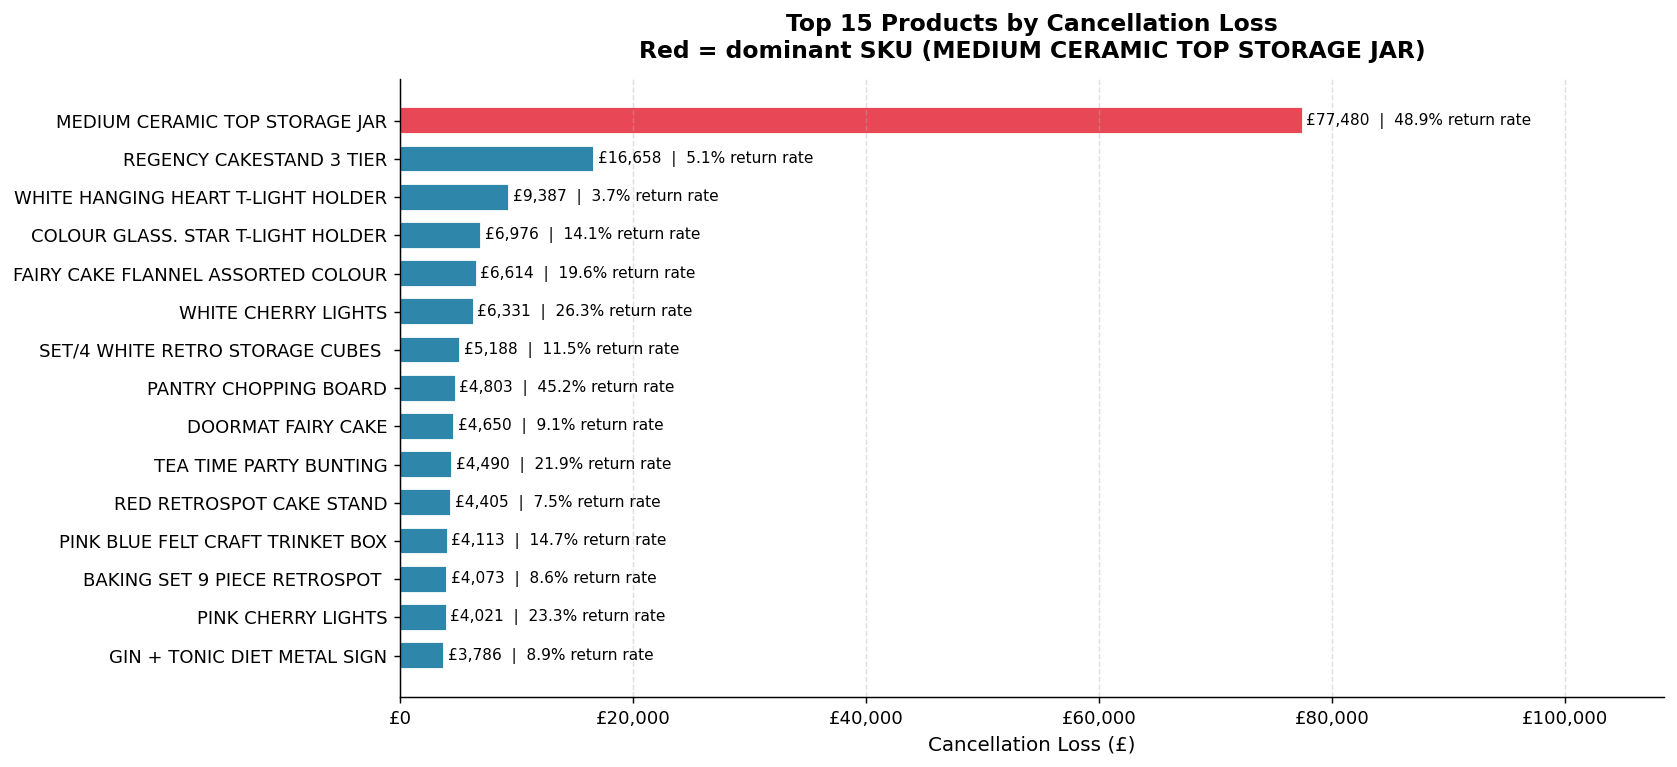


Business Insight: 464 SKUs (15.2%) account for 80% of all cancellation loss.
Less extreme than geographic Pareto — product interventions must be paired with account-level actions.


In [26]:
top15 = prod.head(15).copy()

fig, ax = plt.subplots(figsize=(13, 6))
colors = [C_RED if i == 0 else C_BLUE for i in range(len(top15))]
bars = ax.barh(top15['Description'][::-1], top15['cancel_loss'][::-1],
               color=colors[::-1], edgecolor='white', height=0.7)
for bar, rate in zip(bars, top15['return_rate_pct'][::-1]):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
            f'£{bar.get_width():,.0f}  |  {rate:.1f}% return rate', va='center', fontsize=8.5)
ax.set_xlabel('Cancellation Loss (£)')
ax.set_title('Top 15 Products by Cancellation Loss\nRed = dominant SKU (MEDIUM CERAMIC TOP STORAGE JAR)', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax.set_xlim(0, top15['cancel_loss'].max() * 1.4)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('prod_chart1_pareto.png', bbox_inches='tight')
plt.show()

print()
print(f'Business Insight: {n_80} SKUs ({n_80/n_total*100:.1f}%) account for 80% of all cancellation loss.')
print('Less extreme than geographic Pareto — product interventions must be paired with account-level actions.')

## 2. Price Band Analysis
> **Q2:** Do high-return products share characteristics such as price range?

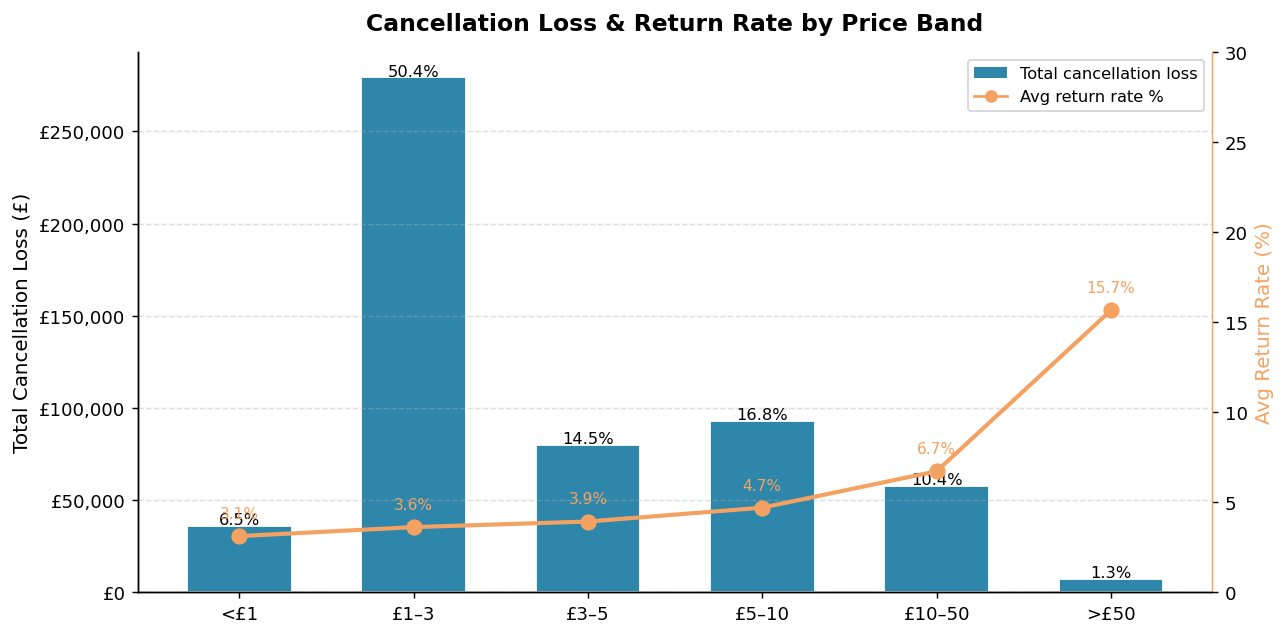


Business Insight — Price Bands:
  £1–3 band carries the most absolute loss (largest SKU count).
  Return RATE climbs with price — items above £50 return at ~16% vs ~3% for cheap items.
  Higher-priced items are riskier per-unit even if fewer in volume.


In [27]:
prod_price = df_product[~df_product['Cancelled']].groupby('StockCode')['Price'].median().rename('median_price')
prod = prod.merge(prod_price.reset_index(), on='StockCode', how='left')

bins   = [0, 1, 3, 5, 10, 50, 9999]
labels = ['<£1', '£1–3', '£3–5', '£5–10', '£10–50', '>£50']
prod['price_band'] = pd.cut(prod['median_price'], bins=bins, labels=labels)

price_grp = prod.groupby('price_band', observed=True).agg(
    num_skus        = ('cancel_loss',     'count'),
    total_loss      = ('cancel_loss',     'sum'),
    avg_return_rate = ('return_rate_pct', 'mean')
).round(2)
price_grp['loss_share_pct'] = (price_grp['total_loss'] / price_grp['total_loss'].sum() * 100).round(1)

fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(price_grp.index, price_grp['total_loss'], color=C_BLUE, edgecolor='white', width=0.6)
for bar, share in zip(bars, price_grp['loss_share_pct']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
             f'{share:.1f}%', ha='center', fontsize=9)
ax1.set_ylabel('Total Cancellation Loss (£)')
ax1.set_title('Cancellation Loss & Return Rate by Price Band', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(price_grp.index, price_grp['avg_return_rate'],
         color=C_ORANGE, marker='o', linewidth=2.3, markersize=8)
for x, y in zip(price_grp.index, price_grp['avg_return_rate']):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8.5, color=C_ORANGE)
ax2.set_ylabel('Avg Return Rate (%)', color=C_ORANGE)
ax2.set_ylim(0, 30)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(C_ORANGE)
legend_el = [
    mpatches.Patch(facecolor=C_BLUE, label='Total cancellation loss'),
    plt.Line2D([0],[0], color=C_ORANGE, marker='o', label='Avg return rate %')
]
ax1.legend(handles=legend_el, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('prod_chart2_pricebands.png', bbox_inches='tight')
plt.show()

print()
print('Business Insight — Price Bands:')
print('  £1–3 band carries the most absolute loss (largest SKU count).')
print('  Return RATE climbs with price — items above £50 return at ~16% vs ~3% for cheap items.')
print('  Higher-priced items are riskier per-unit even if fewer in volume.')

## 3. MEDIUM CERAMIC TOP STORAGE JAR — Quality Issue or Bulk B2B Event?

In [28]:
JAR_SKU = '23166'

jar_cancelled = cancelled_product[cancelled_product['StockCode'] == JAR_SKU].copy()
jar_normal    = df_product[(df_product['StockCode'] == JAR_SKU) & (~df_product['Cancelled'])].copy()

print('=== MEDIUM CERAMIC TOP STORAGE JAR (23166) ===')
print()
print('Cancellation events:')
print(jar_cancelled[['Invoice', cid_col, 'Country', 'Quantity', 'Loss', 'Month']].to_string())
print()

jan_event = jar_cancelled[jar_cancelled['Month'] == '2011-01']
jan_cust  = jan_event[cid_col].values[0]
jan_units = jan_event['Quantity'].abs().values[0]
jan_loss  = jan_event['Loss'].values[0]

print(f'Jan 2011 event: Customer {int(jan_cust)} cancelled {jan_units:,} units = £{jan_loss:,.2f}')
print(f'First normal sale of this SKU: {jar_normal["Month"].min()}')
print()
print('Normal monthly sales after the event:')
print(jar_normal.groupby('Month').agg(
    units=("Quantity", 'sum'), customers=(cid_col, 'nunique')).to_string())

=== MEDIUM CERAMIC TOP STORAGE JAR (23166) ===

Cancellation events:
        Invoice  Customer ID         Country  Quantity      Loss    Month
587085  C541433      12346.0  United Kingdom    -74215  77183.60  2011-01
729086  C554527      15251.0  United Kingdom        -9      9.36  2011-05
759825  C557508      16684.0  United Kingdom      -240    249.60  2011-06
795545  C560540      12415.0       Australia        -1      1.25  2011-07
815818  C562375      14911.0            EIRE       -12     15.00  2011-08
822991  C562952      12749.0  United Kingdom        -1      1.25  2011-08
875309  C567535      15253.0  United Kingdom        -1      1.25  2011-09
878173  C567677      12409.0     Switzerland        -2      2.08  2011-09
919463  C570867      12607.0             USA       -12     15.00  2011-10
946962  C572991      17672.0  United Kingdom        -1      1.25  2011-10

Jan 2011 event: Customer 12346 cancelled 74,215 units = £77,183.60
First normal sale of this SKU: 2011-01

Normal mo

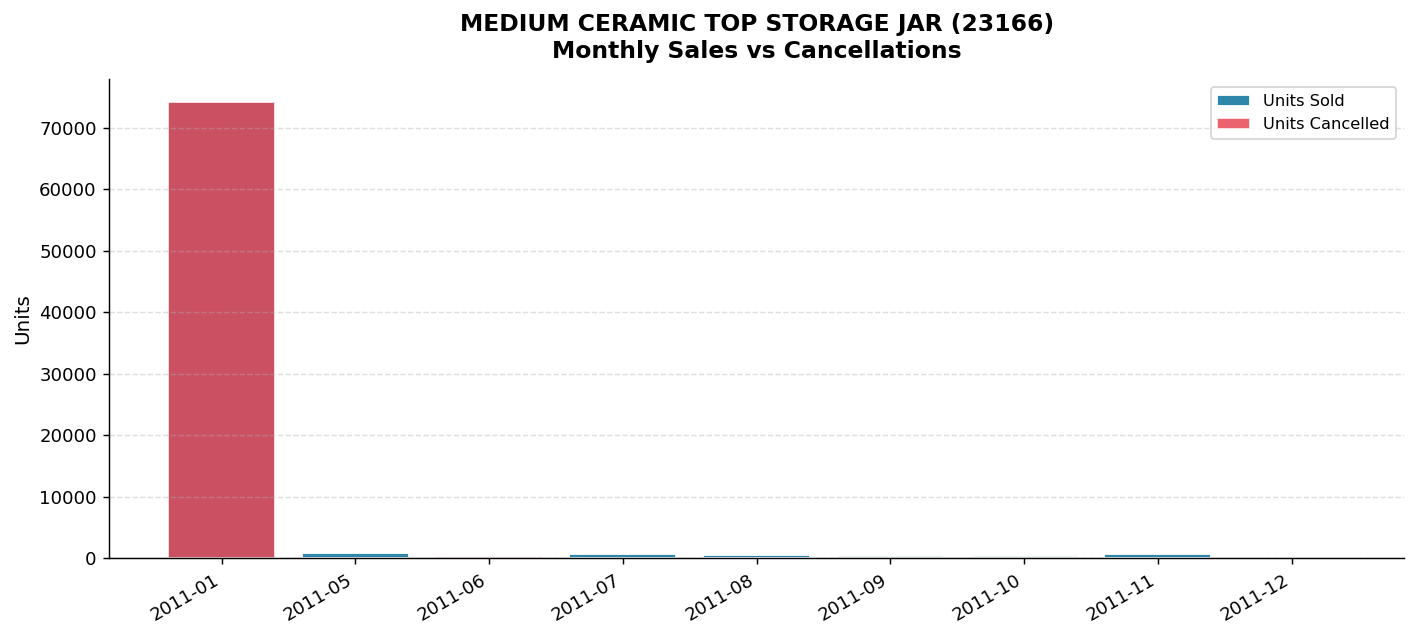


Finding: NOT a quality issue. Single bulk B2B event.
  Customer 12346 cancelled 74,215 units in Jan 2011.
  SKU did not exist before Jan 2011. Return rate <5% in all subsequent months.


In [29]:
jar_monthly_c = jar_cancelled.groupby('Month')['Quantity'].apply(lambda x: x.abs().sum()).rename('cancelled')
jar_monthly_s = jar_normal.groupby('Month')['Quantity'].sum().rename('sold')
jar_monthly   = pd.concat([jar_monthly_s, jar_monthly_c], axis=1).fillna(0)

months = [str(m) for m in jar_monthly.index]
x      = range(len(months))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, jar_monthly['sold'],      color=C_BLUE, label='Units Sold',      edgecolor='white')
ax.bar(x, jar_monthly['cancelled'], color=C_RED,  label='Units Cancelled', edgecolor='white', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(months, rotation=30, ha='right')
ax.set_ylabel('Units')
ax.set_title('MEDIUM CERAMIC TOP STORAGE JAR (23166)\nMonthly Sales vs Cancellations', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('prod_chart3_jar.png', bbox_inches='tight')
plt.show()

print()
print('Finding: NOT a quality issue. Single bulk B2B event.')
print(f'  Customer {int(jan_cust)} cancelled {jan_units:,} units in Jan 2011.')
print('  SKU did not exist before Jan 2011. Return rate <5% in all subsequent months.')

## 4. September 2010 Spike — What Caused ~94k Cancelled Units?

In [30]:
sep = cancelled_product[cancelled_product['Month'] == '2010-09'].copy()

print(f'Sep 2010 cancellations: {len(sep):,} rows')
print(f'Unique customers      : {sep[cid_col].nunique()}')
print(f'Unique invoices       : {sep["Invoice"].nunique()}')
print()

top_inv = (sep.groupby('Invoice')
              .agg(units    = ('Quantity', lambda x: x.abs().sum()),
                   loss     = ('Loss',     'sum'),
                   customer = (cid_col,   'first'),
                   country  = ('Country',  'first'))
              .sort_values('units', ascending=False)
              .head(3))
print('Top invoices by units:')
print(top_inv.to_string())
print()

dom_inv  = top_inv.index[0]
dom_skus = (sep[sep['Invoice'] == dom_inv]
            .groupby('Description')
            .agg(units=('Quantity', lambda x: x.abs().sum()), loss=('Loss', 'sum'))
            .sort_values('units', ascending=False)
            .head(8)
            .reset_index())
print(f'Contents of dominant invoice {dom_inv}:')
print(dom_skus.to_string())

Sep 2010 cancellations: 754 rows
Unique customers      : 253
Unique invoices       : 319

Top invoices by units:
         units      loss  customer country
Invoice                                   
C524235  87167  11880.84   14277.0  France
C524154   2020   3787.88   14911.0    EIRE
C524158    672   1251.20   14911.0    EIRE

Contents of dominant invoice C524235:
                          Description  units     loss
0        SET/6 FRUIT SALAD PAPER CUPS   7128   570.24
1     SET/6 FRUIT SALAD  PAPER PLATES   7008   911.04
2             POP ART PEN CASE & PENS   5184   414.72
3       MULTICOLOUR SPRING FLOWER MUG   4992   499.20
4  BLACK SILVER FLOWER T-LIGHT HOLDER   4752   332.64
5             TEATIME PEN CASE & PENS   4608   368.64
6        WHITE BIRD GARDEN DESIGN MUG   4320   561.60
7      S/4 BLUE ROUND DECOUPAGE BOXES   3936  1653.12


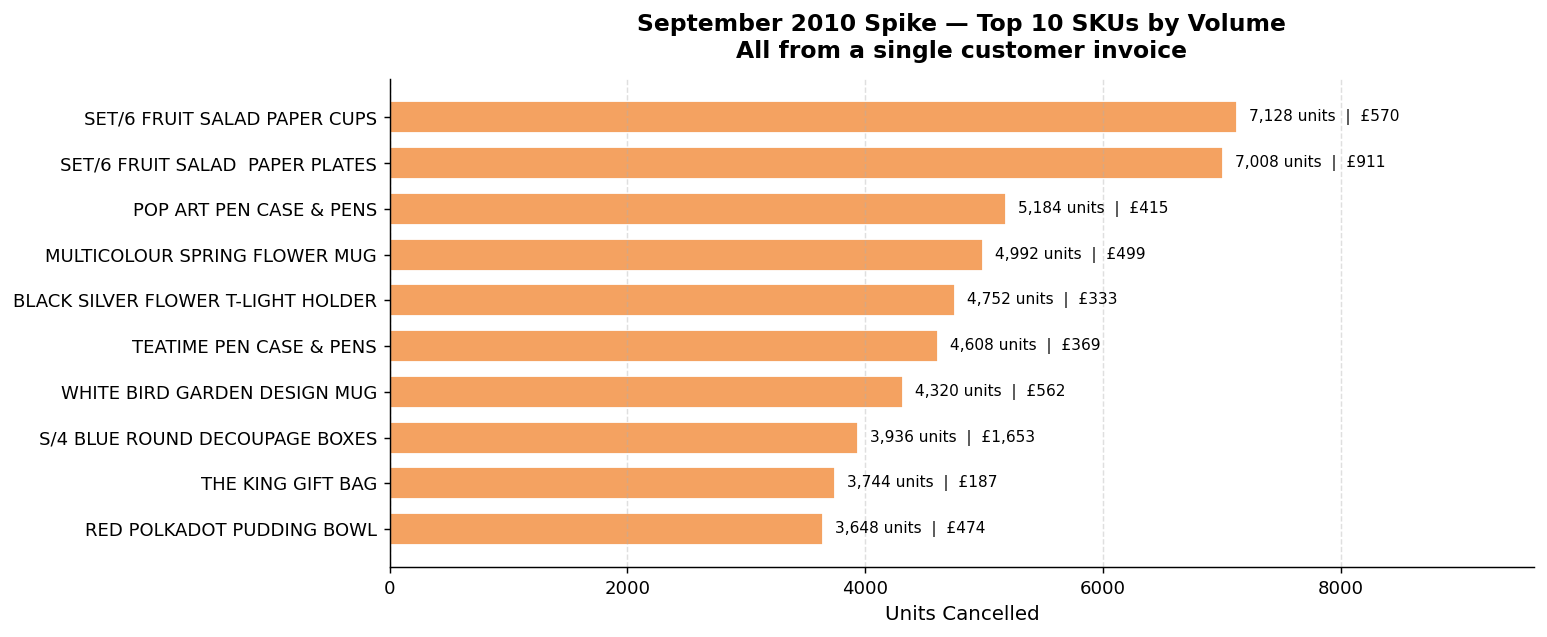


Finding — September 2010 Spike:
  87,167 units (92%) from ONE invoice.
  Customer 14277 (France) — bulk wholesale cancellation across ~20 SKUs.
  Same customer (14277) = 45.5% of France total cancellation loss.
  Account management problem, not a product issue.


In [31]:
top_sep = (sep.groupby(['StockCode','Description'])
              .agg(units=('Quantity', lambda x: x.abs().sum()), loss=('Loss', 'sum'))
              .sort_values('units', ascending=False)
              .head(10)
              .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_sep['Description'][::-1], top_sep['units'][::-1],
        color=C_ORANGE, edgecolor='white', height=0.7)
for i, (units, loss) in enumerate(zip(top_sep['units'][::-1], top_sep['loss'][::-1])):
    ax.text(units + 100, i, f'{units:,} units  |  £{loss:,.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Units Cancelled')
ax.set_title('September 2010 Spike — Top 10 SKUs by Volume\nAll from a single customer invoice', pad=12)
ax.set_xlim(0, top_sep['units'].max() * 1.35)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('prod_chart4_sep2010.png', bbox_inches='tight')
plt.show()

dom_cust  = top_inv['customer'].iloc[0]
dom_units = top_inv['units'].iloc[0]
dom_ctry  = top_inv['country'].iloc[0]
print()
print('Finding — September 2010 Spike:')
print(f'  {dom_units:,} units ({dom_units/sep["Quantity"].abs().sum()*100:.0f}%) from ONE invoice.')
print(f'  Customer {int(dom_cust)} ({dom_ctry}) — bulk wholesale cancellation across ~20 SKUs.')
print('  Same customer (14277) = 45.5% of France total cancellation loss.')
print('  Account management problem, not a product issue.')

## 5. Key Account Product Breakdown — EIRE, Norway, France, Spain

In [32]:
KEY_ACCOUNTS = {
    'EIRE'   : [14911, 14156],
    'Norway' : [15760],
    'France' : [14277, 12536, 12589],
    'Spain'  : [12454, 12539]
}

results = {}

for country, customers in KEY_ACCOUNTS.items():
    sub = cancelled_product[
        (cancelled_product['Country'] == country) &
        (cancelled_product[cid_col].isin(customers))
    ].copy()

    breakdown = (sub.groupby([cid_col, 'StockCode', 'Description'])
                    .agg(times_cancelled = ('Invoice',  'nunique'),
                         total_units     = ('Quantity', lambda x: x.abs().sum()),
                         total_loss      = ('Loss',     'sum'))
                    .sort_values([cid_col, 'total_loss'], ascending=[True, False])
                    .reset_index())

    results[country] = breakdown
    print(f'\n=== {country} ===')
    print(breakdown.head(15).to_string())


=== EIRE ===
    Customer ID StockCode                          Description  times_cancelled  total_units  total_loss
0       14156.0     22838        3 TIER CAKE TIN RED AND CREAM                1           96     1224.00
1       14156.0     22199             FRYING PAN RED POLKADOT                 1          264      990.00
2       14156.0     20715            LITTLE FLOWER SHOPPER BAG                1          400      424.00
3       14156.0     22630                 DOLLY GIRL LUNCH BOX                1          192      316.80
4       14156.0     22363                 GLASS JAR MARMALADE                 1          120      306.00
5       14156.0     22699     ROSES REGENCY TEACUP AND SAUCER                 1          120      306.00
6       14156.0     22935     BAKING MOULD ROSE MILK CHOCOLATE                1           72      198.00
7       14156.0     22936    BAKING MOULD ROSE WHITE CHOCOLATE                1           72      198.00
8       14156.0     20725              LU

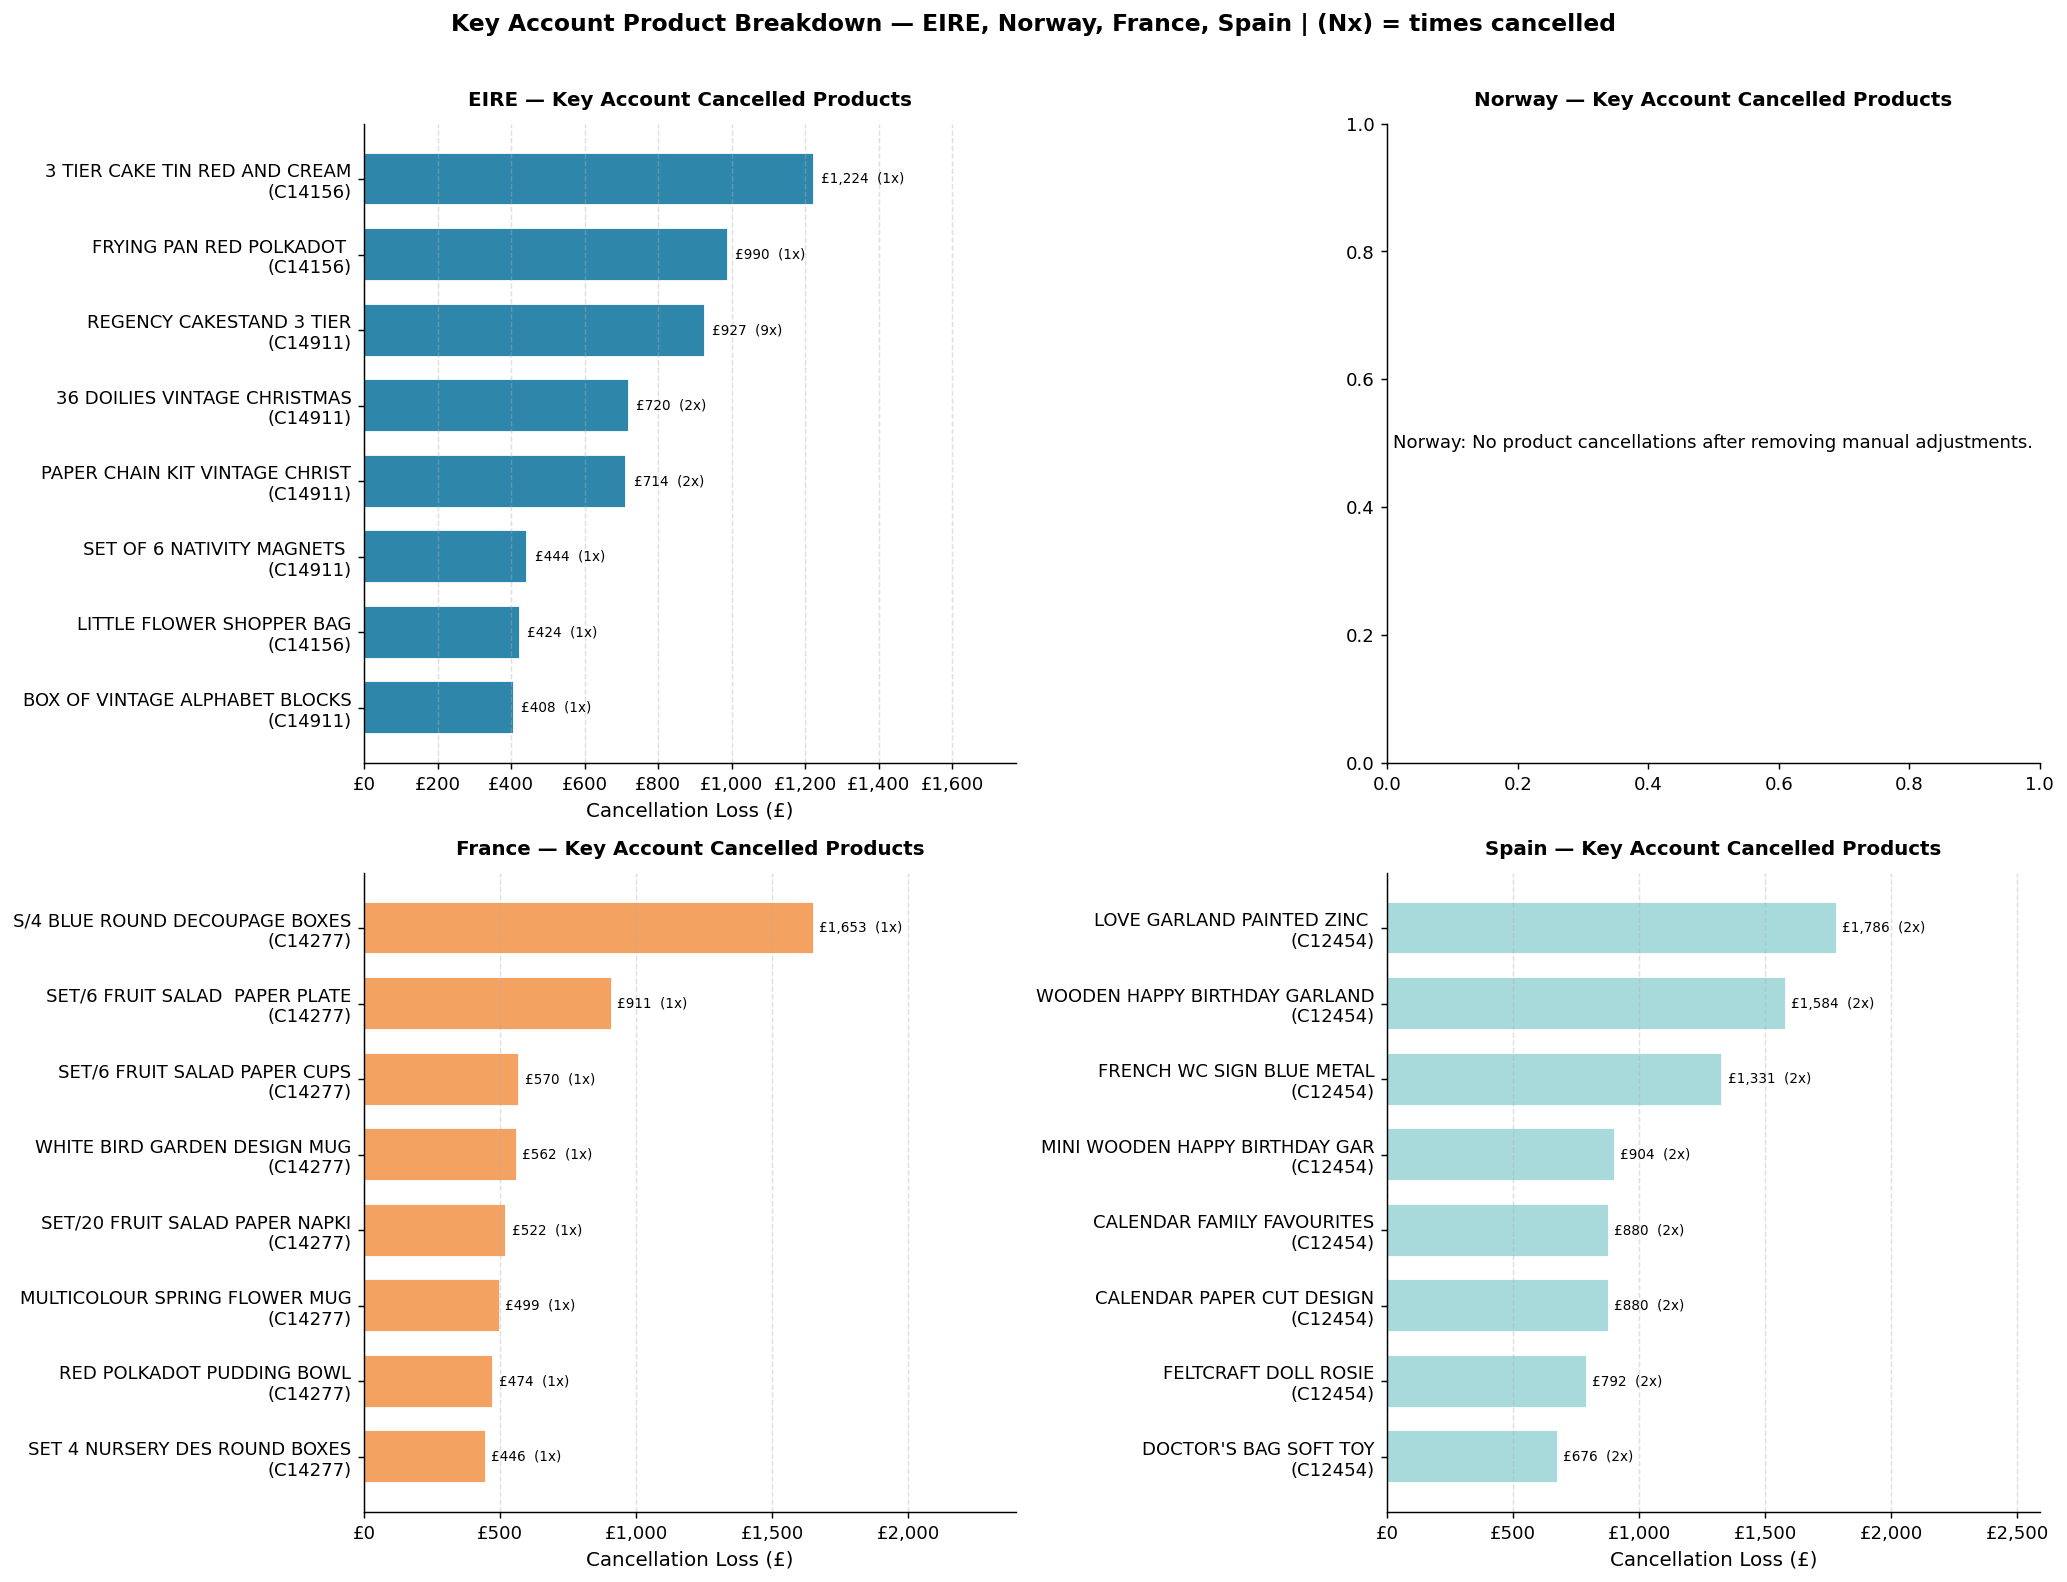


EIRE   : Mixed SKUs. Exception: Customer 14156 cancels REGENCY CAKESTAND repeatedly.
Norway : Negligible real product cancellations after removing Manual codes.
France : One-off bulk event (14277, Sep 2010). No recurring product pattern.
Spain  : RECURRING PATTERN. Customer 12454 cancels same home décor SKUs
         (LOVE GARLAND, WOODEN HAPPY BIRTHDAY GARLAND, FRENCH WC SIGN)
         across multiple invoices. Strongest product-market fit signal in dataset.


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

country_colors = {'EIRE': C_BLUE, 'Norway': C_RED, 'France': C_ORANGE, 'Spain': C_TEAL}

for ax, (country, breakdown) in zip(axes, results.items()):
    top = breakdown.nlargest(8, 'total_loss')

    if top.empty:
        ax.text(0.5, 0.5,
                f'{country}: No product cancellations after removing manual adjustments.',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(f'{country} — Key Account Cancelled Products', fontsize=11, pad=10)
        continue

    labels = [f"{row['Description'][:30]}\n(C{int(row[cid_col])})" for _, row in top.iterrows()]
    bars = ax.barh(labels[::-1], top['total_loss'][::-1],
                   color=country_colors[country], edgecolor='white', height=0.7)
    for bar, times in zip(bars, top['times_cancelled'][::-1]):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                f'£{bar.get_width():,.0f}  ({times}x)', va='center', fontsize=7.5)
    ax.set_title(f'{country} — Key Account Cancelled Products', fontsize=11, pad=10)
    ax.set_xlabel('Cancellation Loss (£)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
    ax.set_xlim(0, top['total_loss'].max() * 1.45)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Key Account Product Breakdown — EIRE, Norway, France, Spain | (Nx) = times cancelled',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prod_chart6_key_accounts.png', bbox_inches='tight')
plt.show()

print()
print('EIRE   : Mixed SKUs. Exception: Customer 14156 cancels REGENCY CAKESTAND repeatedly.')
print('Norway : Negligible real product cancellations after removing Manual codes.')
print('France : One-off bulk event (14277, Sep 2010). No recurring product pattern.')
print('Spain  : RECURRING PATTERN. Customer 12454 cancels same home décor SKUs')
print('         (LOVE GARLAND, WOODEN HAPPY BIRTHDAY GARLAND, FRENCH WC SIGN)')
print('         across multiple invoices. Strongest product-market fit signal in dataset.')

## Product Analysis — Summary of Findings

**Q1 — Pareto:** 464 SKUs (15%) account for 80% of cancellation loss. Less extreme than the geographic Pareto — product interventions must be paired with account-level actions.

**Q2 — Price Bands:** Return *rate* rises with price — items above £50 return at ~16% vs ~3% for cheap items. Absolute loss is concentrated in the £1–3 range due to SKU volume.

**Q3a — Ceramic Jar:** Bulk B2B event. Customer 12346 cancelled 74,215 units in Jan 2011. No quality signal.

**Q3b — Sep 2010 Spike:** Bulk B2B event. Customer 14277 (France) cancelled one large wholesale order across ~20 SKUs. No product pattern.

**Key Account Patterns:** EIRE and France are account problems, not product problems. Norway losses are mostly manual credits (StockCode M). Spain 12454 is the only account showing a genuine recurring product-cancellation pattern — worth further investigation.